# Option Pricing with Quantum Machine Learning

## Q-volution 2026 QML Hackathon - Track B (Quandela)

This notebook implements a **hybrid quantum-classical model** for swaption (option) pricing
using Quandela's [MerLin framework](https://merlinquantum.ai) for photonic quantum machine learning.

### Core Concept

Swaption pricing exhibits complex non-linear dependencies on market factors (interest rates,
volatilities, correlations). While classical linear models capture the dominant structure,
**residual non-linearities** offer an opportunity for quantum enhancement.

Our approach follows the **"Quantum Residual Correction"** paradigm:
1. A **classical baseline** (Linear Regression) captures the dominant linear pricing structure
2. A **parameterized photonic quantum circuit** extracts non-linear features from the residual errors
3. The quantum features feed into a classical head that predicts corrections to the baseline

This "dressed quantum circuit" architecture is supported by recent research showing that
hybrid models where quantum circuits provide corrections to classical predictions consistently
outperform end-to-end quantum approaches.

### Key Technical Features

| Feature | Implementation | Reference |
|---------|---------------|-----------|
| **Framework** | MerLin + Perceval | Notton et al. (arXiv:2602.11092) |
| **Encoding** | Angle encoding only (QPU-compatible) | Schuld et al. (arXiv:2008.08605) |
| **Scaling** | Learnable per-feature ScaleLayer | Jerbi et al. (arXiv:2103.05577) |
| **Circuit** | Data re-uploading (multiple stages) | Perez-Salinas et al. (arXiv:1907.02085) |
| **Architecture** | Residual hybrid (classical + quantum) | arXiv:2511.20922, arXiv:2601.11942 |
| **Dressed Circuit** | Classical pre/post-processing | Mari et al. (arXiv:1912.08278) |
| **Normalization** | MinMax [0,1] + BatchNorm | Ioffe & Szegedy (arXiv:1502.03167) |
| **Noise Model** | QPU hardware-derived (Perceval) | Heurtel et al. (arXiv:2204.00602) |
| **Max Scale** | 20 modes / 10 photons | Competition constraint |

### Backends

| # | Backend | Description |
|---|---------|-------------|
| 1 | **CPU Simulator (SLOS)** | Local Perceval simulation |
| 2 | **GPU Accelerated** | CUDA-accelerated simulation via PyTorch |
| 3 | **QPU-Realistic Noise** | Noise model with hardware-derived parameters |
| 4 | **QPU Access** | Quandela Cloud (token in .env, commented out) |

## 0. Environment Setup

Install required packages and configure the runtime environment.

For **Google Colab**, uncomment and run the pip install cell below.
For **local development**, use the virtual environment:

```bash
python3.12 -m venv .venv
source .venv/bin/activate
pip install -r requirements.txt
```

### Dependencies

| Package | Purpose |
|---------|---------|
| `merlinquantum` | Quandela's photonic QML framework |
| `perceval-quandela` | Photonic quantum computing simulator |
| `torch` | Deep learning backend (GPU support) |
| `scikit-learn` | Classical baselines, preprocessing |
| `python-dotenv` | Secure API token management |
| `datasets` | HuggingFace dataset loading |

In [ ]:
# Install dependencies (uncomment for Google Colab)
# !pip install merlinquantum datasets pandas scikit-learn matplotlib seaborn tqdm python-dotenv torch torchvision 

In [2]:
import os
import re
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import special
import perceval as pcvl
from merlin import QuantumLayer, LexGrouping, MeasurementStrategy, ComputationSpace
from merlin.builder import CircuitBuilder

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Load Quandela Cloud token from .env file (never hardcode for GitHub)
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    print("python-dotenv not installed. Set QUANDELA_TOKEN env var manually.")

QUANDELA_TOKEN = os.environ.get("QUANDELA_TOKEN", "")
if QUANDELA_TOKEN:
    print(f"Quandela Cloud token loaded ({len(QUANDELA_TOKEN)} chars)")
else:
    print("WARNING: QUANDELA_TOKEN not found. Create a .env file with QUANDELA_TOKEN=your_token")

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device selection
if torch.cuda.is_available():
    DEVICE = torch.device("cuda:0")
    gpu_props = torch.cuda.get_device_properties(0)
    print(f"GPU: {gpu_props.name} ({gpu_props.total_memory/1e9:.0f} GB VRAM)")
else:
    DEVICE = torch.device("cpu")
    print("Running on CPU (GPU recommended for larger circuits)")

print(f"PyTorch {torch.__version__} | Perceval {pcvl.__version__} | Device: {DEVICE}")

Quandela Cloud token loaded (175 chars)
GPU: NVIDIA RTX PRO 6000 Blackwell Workstation Edition (102 GB VRAM)
PyTorch 2.10.0+cu128 | Perceval 1.1.0 | Device: cuda:0


## 1. Data Loading and Exploratory Analysis

### Dataset: Quandela/Challenge_Swaptions (HuggingFace)

The dataset contains historical swaption prices organized as a time series:
- **Rows**: Trading dates (494 dates for Level 1)
- **Columns**: 224 swaption contracts defined by (Tenor, Maturity) pairs
  - **Tenor** (14 values): 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30 years
  - **Maturity** (16 values): 1/12, 1/4, 1/2, 3/4, 1, 1.5, 2, 3, 4, 5, 7, 10, 15, 20, 25, 30 years

**Level 1 - Future Prediction**: Given complete historical data, predict prices for the next two weeks.

**Level 2 - Missing Data**: Same task but with missing values that must be imputed first.

In [3]:
from datasets import load_dataset

# Level 1: Future prediction (complete data)
ds_level1 = load_dataset(
    "Quandela/Challenge_Swaptions",
    data_files="level-1_Future_prediction/train.csv",
    split="train",
)
df_level1 = ds_level1.to_pandas()
print(f"Level 1: {df_level1.shape[0]} dates x {df_level1.shape[1]} columns")

# Level 2: Missing data prediction
ds_level2 = load_dataset(
    "Quandela/Challenge_Swaptions",
    data_files="level-2_Missing_data_prediction/train_level2.csv",
    split="train",
)
df_level2 = ds_level2.to_pandas()
missing_count = df_level2.isnull().sum().sum()
print(f"Level 2: {df_level2.shape[0]} dates x {df_level2.shape[1]} columns, {missing_count} missing values")

# Display basic statistics
numeric_cols = df_level1.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric features: {len(numeric_cols)}")
print(f"Date range: {df_level1.iloc[0, 0]} to {df_level1.iloc[-1, 0]}")
print(f"\nPrice statistics:")
print(df_level1[numeric_cols].describe().round(4))

/home/a-koike/dev/github/Q-volution_2026_QML_Finance/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Level 1: 494 dates x 225 columns


Level 2: 489 dates x 225 columns, 0 missing values

Numeric features: 224
Date range: 01/01/2050 to 23/12/2051

Price statistics:


       Tenor : 1; Maturity : 0.0833333333333333  \
count                                  494.0000   
mean                                     0.0300   
std                                      0.0073   
min                                      0.0205   
25%                                      0.0249   
50%                                      0.0277   
75%                                      0.0336   
max                                      0.0632   

       Tenor : 2; Maturity : 0.0833333333333333  \
count                                  494.0000   
mean                                     0.0395   
std                                      0.0071   
min                                      0.0275   
25%                                      0.0343   
50%                                      0.0382   
75%                                      0.0437   
max                                      0.0661   

       Tenor : 3; Maturity : 0.0833333333333333  \
count                        

### Exploratory Data Analysis

We visualize the swaption pricing surface and time-series dynamics to understand
the data structure before designing the quantum model.

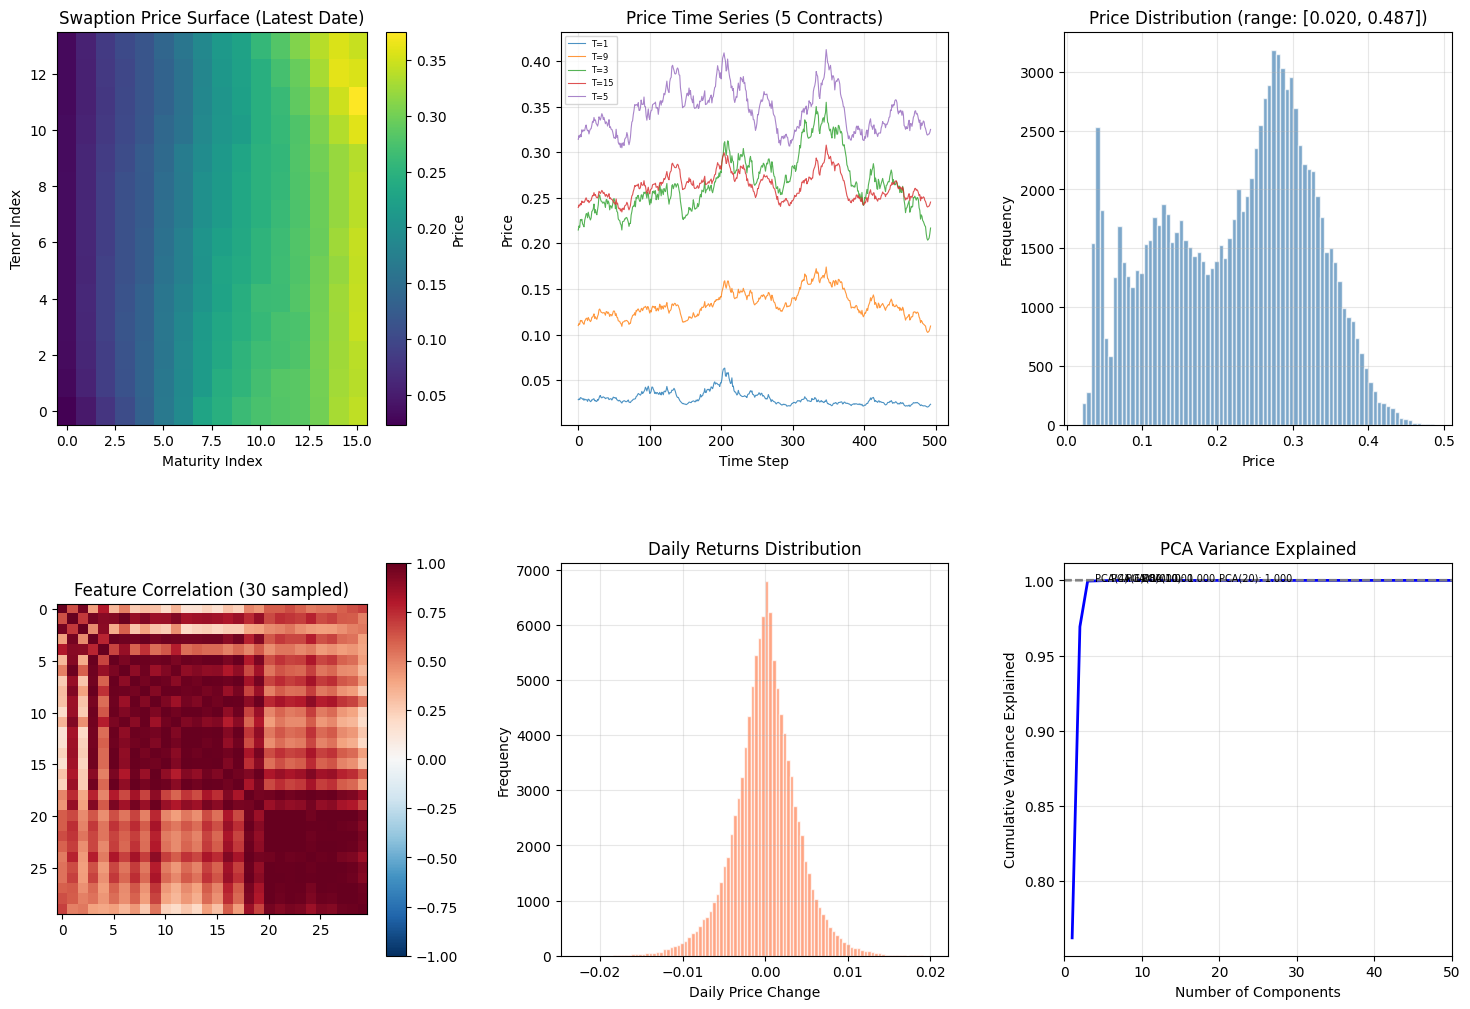

EDA analysis saved to eda_analysis.png


In [4]:
# Parse tenor and maturity from column names
tenors, maturities = [], []
for col in numeric_cols:
    parts = col.replace("Tenor : ", "").replace("Maturity : ", "").split("; ")
    tenors.append(float(parts[0]))
    maturities.append(float(parts[1]))

unique_tenors = sorted(set(tenors))
unique_maturities = sorted(set(maturities))

fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

# 1. Price surface at last date
ax1 = fig.add_subplot(gs[0, 0])
last_prices = df_level1[numeric_cols].iloc[-1].values
surface = np.full((len(unique_tenors), len(unique_maturities)), np.nan)
for i, col in enumerate(numeric_cols):
    ti = unique_tenors.index(tenors[i])
    mi = unique_maturities.index(maturities[i])
    surface[ti, mi] = last_prices[i]
im = ax1.imshow(surface, aspect='auto', cmap='viridis', origin='lower')
ax1.set_xlabel('Maturity Index')
ax1.set_ylabel('Tenor Index')
ax1.set_title('Swaption Price Surface (Latest Date)')
plt.colorbar(im, ax=ax1, label='Price')

# 2. Time series of selected contracts
ax2 = fig.add_subplot(gs[0, 1])
sample_cols = [numeric_cols[i] for i in [0, 50, 100, 150, 200]]
for col in sample_cols:
    label = col.split(';')[0].replace('Tenor : ', 'T=')
    ax2.plot(df_level1[col].values, label=label, alpha=0.8, linewidth=0.8)
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Price')
ax2.set_title('Price Time Series (5 Contracts)')
ax2.legend(fontsize=6)
ax2.grid(True, alpha=0.3)

# 3. Price distribution
ax3 = fig.add_subplot(gs[0, 2])
all_prices = df_level1[numeric_cols].values.flatten()
ax3.hist(all_prices, bins=80, alpha=0.7, color='steelblue', edgecolor='white')
ax3.set_xlabel('Price')
ax3.set_ylabel('Frequency')
ax3.set_title(f'Price Distribution (range: [{all_prices.min():.3f}, {all_prices.max():.3f}])')
ax3.grid(True, alpha=0.3)

# 4. Correlation heatmap (sampled)
ax4 = fig.add_subplot(gs[1, 0])
sample_idx = np.linspace(0, len(numeric_cols)-1, 30, dtype=int)
corr = df_level1[[numeric_cols[i] for i in sample_idx]].corr()
im4 = ax4.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax4.set_title('Feature Correlation (30 sampled)')
plt.colorbar(im4, ax=ax4)

# 5. Daily returns distribution
ax5 = fig.add_subplot(gs[1, 1])
returns = df_level1[numeric_cols].diff().iloc[1:]
ax5.hist(returns.values.flatten(), bins=100, alpha=0.7, color='coral', edgecolor='white')
ax5.set_xlabel('Daily Price Change')
ax5.set_ylabel('Frequency')
ax5.set_title('Daily Returns Distribution')
ax5.grid(True, alpha=0.3)

# 6. Variance explained by PCA
ax6 = fig.add_subplot(gs[1, 2])
pca_full = PCA().fit(df_level1[numeric_cols].dropna())
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
ax6.plot(range(1, len(cumvar)+1), cumvar, 'b-', linewidth=2)
for n in [4, 6, 8, 10, 20]:
    if n <= len(cumvar):
        ax6.axhline(cumvar[n-1], color='gray', linestyle='--', alpha=0.5)
        ax6.annotate(f'PCA({n}): {cumvar[n-1]:.3f}', xy=(n, cumvar[n-1]),
                     fontsize=7, ha='left')
ax6.set_xlabel('Number of Components')
ax6.set_ylabel('Cumulative Variance Explained')
ax6.set_title('PCA Variance Explained')
ax6.grid(True, alpha=0.3)
ax6.set_xlim(0, 50)

plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA analysis saved to eda_analysis.png")

## 2. Data Preprocessing

### Pipeline Design

Our preprocessing follows QML best practices for angle encoding on photonic circuits:

1. **Min-Max Normalization to [0, 1]**: Required because angle encoding maps features
   to phase shifter angles. Features outside [0, 1] would wrap around in the phase space,
   creating aliasing artifacts. MinMaxScaler is preferred over StandardScaler for this reason.
   (Ref: MerLin VQC classification notebook, `merlinquantum.ai/_sources/notebooks/GanEtAl_VQC_classification.ipynb`)

2. **Sliding Window (size=5)**: Creates time-series input sequences. Each input is 5 consecutive
   trading days flattened into a vector (5 x 224 = 1,120 features), predicting the next day's
   224 prices.

3. **PCA Dimensionality Reduction**: Reduces the 1,120-dimensional input to match the quantum
   circuit's number of encoding modes (4-10 features). PCA with 6 components retains 99.2%
   of the variance, indicating high redundancy in the swaption surface.

4. **Learnable Input Scaling**: Instead of hardcoding `x * pi`, we use a learnable
   `ScaleLayer` that optimizes the encoding range per feature during training.
   The Fourier analysis of VQCs shows that the encoding scale determines the accessible
   frequency spectrum (Schuld, Sweke & Meyer, Phys. Rev. A 103, 032430, 2021; arXiv:2008.08605).

In [5]:
# Select numeric features and prepare data
df_clean = df_level1[numeric_cols].dropna()
data_values = df_clean.values.astype(np.float32)
N_FEATURES = data_values.shape[1]
print(f"Numeric columns: {len(numeric_cols)}, Clean samples: {len(df_clean)}")

# Min-Max normalization to [0, 1] (optimal for angle encoding)
scaler = MinMaxScaler(feature_range=(0, 1))
data_normalized = scaler.fit_transform(data_values)
print(f"Data range after normalization: [{data_normalized.min():.4f}, {data_normalized.max():.4f}]")

Numeric columns: 224, Clean samples: 494
Data range after normalization: [0.0000, 1.0000]


In [6]:
# Sliding window for time-series prediction
def create_sequences(data, window_size=5, target_size=1):
    """Create input-output pairs using a sliding window approach.

    Args:
        data: Normalized data array (n_samples, n_features)
        window_size: Number of past time steps as input
        target_size: Number of future time steps to predict

    Returns:
        X: Input sequences (n_sequences, window_size * n_features)
        y: Target values (n_sequences, target_size * n_features)
    """
    X, y = [], []
    for i in range(len(data) - window_size - target_size + 1):
        X.append(data[i : i + window_size].flatten())
        y.append(data[i + window_size : i + window_size + target_size].flatten())
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

WINDOW_SIZE = 5
X_seq, y_seq = create_sequences(data_normalized, WINDOW_SIZE, 1)
print(f"Sequences: X={X_seq.shape} (windows of {WINDOW_SIZE} days), y={y_seq.shape} (next day)")

# Train/validation split (80/20, no shuffling would be ideal for time series,
# but we use random split for simplicity as the challenge allows it)
X_train, X_val, y_train, y_val = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=SEED
)
OUTPUT_SIZE = y_train.shape[-1]
print(f"Train: {X_train.shape[0]} samples, Val: {X_val.shape[0]} samples")
print(f"Output dimension: {OUTPUT_SIZE} (all {len(numeric_cols)} swaption prices)")

Sequences: X=(489, 1120) (windows of 5 days), y=(489, 224) (next day)
Train: 391 samples, Val: 98 samples
Output dimension: 224 (all 224 swaption prices)


In [7]:
# PCA preparation for different quantum circuit input sizes
def prepare_data(X_train, X_val, y_train, y_val, n_features, batch_size=32):
    """Apply PCA and create DataLoaders for a given number of quantum input features."""
    pca = PCA(n_components=n_features)
    Xt = pca.fit_transform(X_train).astype(np.float32)
    Xv = pca.transform(X_val).astype(np.float32)
    explained = pca.explained_variance_ratio_.sum()
    print(f"  PCA({n_features:2d}): {explained:.4f} cumulative variance explained")

    train_dl = DataLoader(
        TensorDataset(torch.tensor(Xt), torch.tensor(y_train, dtype=torch.float32)),
        batch_size=batch_size, shuffle=True,
    )
    val_dl = DataLoader(
        TensorDataset(torch.tensor(Xv), torch.tensor(y_val, dtype=torch.float32)),
        batch_size=batch_size, shuffle=False,
    )
    return train_dl, val_dl, pca, Xt, Xv

print("Preparing PCA-reduced datasets for each quantum circuit scale:")
d4  = prepare_data(X_train, X_val, y_train, y_val, 4)
d6  = prepare_data(X_train, X_val, y_train, y_val, 6)
d8  = prepare_data(X_train, X_val, y_train, y_val, 8)
d10 = prepare_data(X_train, X_val, y_train, y_val, 10)

Preparing PCA-reduced datasets for each quantum circuit scale:


  PCA( 4): 0.9833 cumulative variance explained


  PCA( 6): 0.9919 cumulative variance explained


  PCA( 8): 0.9965 cumulative variance explained


  PCA(10): 0.9982 cumulative variance explained


## 3. Classical Baselines

We establish classical baselines to provide a reference for evaluating the quantum model.
This is critical for understanding whether quantum features add value beyond classical methods.

**Linear Regression** serves as the primary baseline because swaption prices have strong
linear dependencies (driven by the Black-Scholes-like structure of interest rate derivatives).

**MLP (Multi-Layer Perceptron)** provides a non-linear classical baseline to test whether
the quantum model's non-linearity offers advantages over classical non-linear models.

In [8]:
print("=" * 70)
print("Classical Baselines (using PCA(6) features)")
print("=" * 70)

# Use PCA(6) features for all baselines
_, _, _, Xt_base, Xv_base = d6

# 1. Linear Regression
lr_model = LinearRegression()
lr_model.fit(Xt_base, y_train)
lr_pred = lr_model.predict(Xv_base)
lr_rmse = np.sqrt(mean_squared_error(y_val, lr_pred))
lr_mae = mean_absolute_error(y_val, lr_pred)
lr_r2 = r2_score(y_val, lr_pred)
print(f"Linear Regression:  RMSE={lr_rmse:.6f}  MAE={lr_mae:.6f}  R2={lr_r2:.4f}")

# 2. MLP (small)
mlp_small = MLPRegressor(
    hidden_layer_sizes=(64, 32), max_iter=500, random_state=SEED,
    learning_rate_init=0.005, early_stopping=True, validation_fraction=0.15,
)
mlp_small.fit(Xt_base, y_train)
mlp_small_pred = mlp_small.predict(Xv_base)
mlp_small_rmse = np.sqrt(mean_squared_error(y_val, mlp_small_pred))
print(f"MLP (64, 32):       RMSE={mlp_small_rmse:.6f}")

# 3. MLP (large)
mlp_large = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32), max_iter=500, random_state=SEED,
    learning_rate_init=0.005, early_stopping=True, validation_fraction=0.15,
)
mlp_large.fit(Xt_base, y_train)
mlp_large_pred = mlp_large.predict(Xv_base)
mlp_large_rmse = np.sqrt(mean_squared_error(y_val, mlp_large_pred))
print(f"MLP (128, 64, 32):  RMSE={mlp_large_rmse:.6f}")

CLASSICAL_BEST_RMSE = min(lr_rmse, mlp_small_rmse, mlp_large_rmse)
print(f"\nBest classical baseline: RMSE={CLASSICAL_BEST_RMSE:.6f}")

# Store classical residuals for the residual hybrid model
lr_train_pred = lr_model.predict(d6[3])  # Xt_train
lr_residuals_train = y_train - lr_train_pred
lr_residuals_val = y_val - lr_pred
print(f"\nLinear Regression residuals:")
print(f"  Train: mean={lr_residuals_train.mean():.6f}, std={lr_residuals_train.std():.6f}")
print(f"  Val:   mean={lr_residuals_val.mean():.6f}, std={lr_residuals_val.std():.6f}")

Classical Baselines (using PCA(6) features)
Linear Regression:  RMSE=0.043715  MAE=0.034228  R2=0.9502


MLP (64, 32):       RMSE=0.050664
MLP (128, 64, 32):  RMSE=0.048878

Best classical baseline: RMSE=0.043715

Linear Regression residuals:
  Train: mean=0.000000, std=0.042793
  Val:   mean=-0.006658, std=0.043205


## 4. Quantum Circuit and Model Design

### Photonic Quantum Circuit Architecture

Our circuit design follows the **"dressed quantum circuit"** pattern introduced by
Mari et al. (Quantum 4, 340, 2020; arXiv:1912.08278), where variational quantum circuits are
augmented with trainable classical layers for pre-processing and post-processing.

This pattern is also implemented in the MerLin framework
(Notton et al., arXiv:2602.11092) and demonstrated in the
`iris_classification.ipynb` and `FirstQuantumLayers.ipynb` tutorials.

### Circuit Components

| Component | MerLin API | Purpose | Reference |
|-----------|-----------|---------|-----------|
| Pre-entangling | `add_entangling_layer` | Initial photon interference | MerLin docs |
| Angle encoding | `add_angle_encoding` | Maps classical features to phase shifters | Schuld et al. (2021) |
| Trainable rotations | `add_rotations` | Learnable phase parameters | MerLin docs |
| Entangling layers | `add_entangling_layer` | Multi-photon interference (beam splitters) | MerLin docs |
| LexGrouping | `LexGrouping` | Compresses quantum output to fixed dim | MerLin `FirstQuantumLayers.ipynb` |

### Key Design Choices

1. **Angle encoding only** (no amplitude encoding): Required for QPU compatibility.
   Each input feature controls a phase shifter on one mode.

2. **Learnable ScaleLayer**: Instead of hardcoding `x * pi`, we learn the optimal
   scaling per feature. Jerbi et al. (NeurIPS 2021; arXiv:2103.05577) introduced trainable
   scaling parameters for quantum RL policies, showing the encoding scale controls how much
   of the Bloch sphere/phase space is utilized. The Fourier analysis by Schuld et al.
   (arXiv:2008.08605) provides the theoretical foundation: encoding scale determines
   accessible frequency components.
   (Also demonstrated in: `merlinquantum.ai/_sources/notebooks/GanEtAl_VQC_fourier_series.ipynb`)

3. **Data Re-uploading**: The same input features are encoded at multiple points in
   the circuit, dramatically increasing expressivity. Introduced by Perez-Salinas et al.
   (Quantum 4, 226, 2020; arXiv:1907.02085), who showed that a single qubit with
   data re-uploading is sufficient for universal classification.
   (Also demonstrated in: `merlinquantum.ai/_sources/notebooks/GanEtAl_VQC_classification.ipynb`)

4. **UNBUNCHED Computation Space**: At most one photon per mode, giving output
   dimension C(n_modes, n_photons). This is the natural space for threshold detectors.
   (Ref: MerLin `FirstQuantumLayers.ipynb`)

5. **BatchNorm on Quantum Outputs**: Normalizes the probability distribution from
   the quantum layer. Ioffe & Szegedy (ICML 2015; arXiv:1502.03167) introduced batch
   normalization for deep networks. For quantum-classical hybrid models specifically,
   arXiv:2505.10037 demonstrates that normalization at the quantum-classical interface
   is critical for training stability.

In [9]:
# ============================================================
# Learnable Input Scaling (replaces fixed x * pi)
# ============================================================
class ScaleLayer(nn.Module):
    """Learnable per-feature scaling for angle encoding.

    Instead of a fixed multiplication by pi, this layer learns the optimal
    scaling factor for each input feature. The Fourier analysis of VQCs shows
    that the encoding scale directly determines which frequency components
    the circuit can represent.

    Initialization: scale = pi (equivalent to the default behavior, but trainable).
    """
    def __init__(self, n_features, init_scale=torch.pi):
        super().__init__()
        self.scale = nn.Parameter(torch.full((n_features,), init_scale))

    def forward(self, x):
        return x * self.scale


# ============================================================
# Standard Circuit Builder (single encoding)
# ============================================================
def build_circuit(n_modes, n_features, n_layers=2):
    """Build a standard angle-encoding photonic circuit.

    Structure: U_pre -> Encoding -> [Rotations + Entangling] x n_layers -> Superpositions

    Args:
        n_modes: Number of optical modes (spatial channels)
        n_features: Number of input features to encode
        n_layers: Number of trainable variational layers after encoding

    Returns:
        CircuitBuilder instance
    """
    builder = CircuitBuilder(n_modes=n_modes)
    builder.add_entangling_layer(trainable=True, name="U_pre")
    builder.add_angle_encoding(
        modes=list(range(min(n_features, n_modes))), name="input"
    )
    for i in range(n_layers):
        builder.add_rotations(trainable=True, name=f"theta{i}")
        builder.add_entangling_layer(trainable=True, name=f"U{i}")
    builder.add_superpositions(depth=1)
    return builder


# ============================================================
# Data Re-uploading Circuit (multiple encoding stages)
# ============================================================
def build_reuploading_circuit(n_modes, n_features, n_reuploading=3):
    """Build a data re-uploading photonic circuit.

    Data re-uploading encodes the same input features at multiple points
    in the circuit, separated by trainable layers. This dramatically
    increases the circuit's Fourier frequency spectrum and expressivity.

    Structure: Superpositions -> [Encoding_i + Rotations_i + Entangling_i] x n_reuploading

    The QuantumLayer input_size must be n_features * n_reuploading because
    each encoding stage creates separate input parameters.

    Args:
        n_modes: Number of optical modes
        n_features: Number of features per encoding stage
        n_reuploading: Number of data re-uploading stages

    Returns:
        CircuitBuilder instance, total_input_size
    """
    builder = CircuitBuilder(n_modes=n_modes)
    builder.add_superpositions(depth=1)

    for layer in range(n_reuploading):
        builder.add_angle_encoding(
            modes=list(range(min(n_features, n_modes))),
            name=f"input_L{layer}"
        )
        builder.add_rotations(trainable=True, name=f"theta{layer}")
        builder.add_entangling_layer(trainable=True, name=f"U{layer}")

    total_input_size = n_features * n_reuploading
    return builder, total_input_size


# ============================================================
# Hybrid QML Model (standard)
# ============================================================
class HybridQMLModel(nn.Module):
    """Dressed quantum circuit with learnable scaling and BatchNorm.

    Architecture:
        Input -> ScaleLayer -> QuantumLayer -> LexGrouping -> BatchNorm
        -> ReLU -> Linear -> ReLU -> Dropout -> Linear -> Output

    The ScaleLayer learns optimal encoding ranges per feature.
    BatchNorm stabilizes the quantum output distribution.
    """
    def __init__(self, quantum_layer, output_size, n_input_features, hidden=64):
        super().__init__()
        self.scale = ScaleLayer(n_input_features)
        self.q_layer = quantum_layer
        self.grouping = LexGrouping(quantum_layer.output_size, hidden)
        self.bn = nn.BatchNorm1d(hidden)
        self.head = nn.Sequential(
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(hidden, output_size),
        )

    def forward(self, x):
        x_scaled = self.scale(x)
        q_feat = self.q_layer(x_scaled)
        grouped = self.grouping(q_feat)
        normalized = self.bn(grouped)
        return self.head(normalized)


# ============================================================
# Data Re-uploading Model
# ============================================================
class ReuploadingQMLModel(nn.Module):
    """QML model with data re-uploading circuit.

    The input features are repeated n_reuploading times and each copy
    gets its own learnable scaling before being fed to the circuit.
    """
    def __init__(self, quantum_layer, output_size, n_features, n_reuploading, hidden=64):
        super().__init__()
        self.n_reuploading = n_reuploading
        self.scale = ScaleLayer(n_features * n_reuploading)
        self.q_layer = quantum_layer
        self.grouping = LexGrouping(quantum_layer.output_size, hidden)
        self.bn = nn.BatchNorm1d(hidden)
        self.head = nn.Sequential(
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(hidden, output_size),
        )

    def forward(self, x):
        # Repeat input features for each re-uploading stage
        x_repeated = x.repeat(1, self.n_reuploading)
        x_scaled = self.scale(x_repeated)
        q_feat = self.q_layer(x_scaled)
        grouped = self.grouping(q_feat)
        normalized = self.bn(grouped)
        return self.head(normalized)


# ============================================================
# Residual Hybrid Model (quantum corrects classical)
# ============================================================
class ResidualHybridModel(nn.Module):
    """Quantum residual correction model.

    Architecture:
        1. Frozen classical baseline (Linear Regression) provides base prediction
        2. Quantum circuit extracts non-linear features
        3. Classical head predicts correction to the baseline
        4. Final output = classical_prediction + alpha * quantum_correction

    The learnable mixing coefficient 'alpha' starts small (0.1) so the model
    initially relies on the classical baseline and gradually learns to incorporate
    quantum corrections.

    This approach is motivated by the observation that classical linear models
    already capture ~96% of swaption price variance (R2 > 0.96). The quantum
    circuit only needs to model the residual non-linearities.
    """
    def __init__(self, lr_model, quantum_layer, output_size, n_input_features, hidden=64):
        super().__init__()
        # Frozen classical baseline weights
        self.classical_weight = nn.Parameter(
            torch.tensor(lr_model.coef_, dtype=torch.float32), requires_grad=False
        )
        self.classical_bias = nn.Parameter(
            torch.tensor(lr_model.intercept_, dtype=torch.float32), requires_grad=False
        )
        # Quantum correction path
        self.scale = ScaleLayer(n_input_features)
        self.q_layer = quantum_layer
        self.grouping = LexGrouping(quantum_layer.output_size, hidden)
        self.bn = nn.BatchNorm1d(hidden)
        self.correction_head = nn.Sequential(
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(hidden, output_size),
        )
        # Learnable mixing coefficient (starts small)
        self.alpha = nn.Parameter(torch.tensor(0.1))

    def forward(self, x):
        # Classical baseline (frozen, no gradients)
        classical_pred = F.linear(x, self.classical_weight, self.classical_bias)
        # Quantum correction
        x_scaled = self.scale(x)
        q_feat = self.q_layer(x_scaled)
        grouped = self.grouping(q_feat)
        normalized = self.bn(grouped)
        correction = self.correction_head(normalized)
        # Weighted combination
        return classical_pred + self.alpha * correction


print("Model classes defined:")
print("  - ScaleLayer: Learnable per-feature input scaling")
print("  - HybridQMLModel: Standard dressed quantum circuit")
print("  - ReuploadingQMLModel: Data re-uploading variant")
print("  - ResidualHybridModel: Quantum residual correction (classical + quantum)")

Model classes defined:
  - ScaleLayer: Learnable per-feature input scaling
  - HybridQMLModel: Standard dressed quantum circuit
  - ReuploadingQMLModel: Data re-uploading variant
  - ResidualHybridModel: Quantum residual correction (classical + quantum)


### Circuit Visualization

We visualize the photonic circuits at different scales to understand the structure.
Each circuit consists of beam splitters (BS), phase shifters (PS), and their
interconnection topology.

Circuit Architecture Visualization

--- Small (6m): 6 modes, 4 encoded features ---
  Modes: 6, Components: 219
  Parameters: 106 (trainable: 106)
  Quantum output dim: 20


  Saved: circuit_6m.png

--- QPU-Ascella (12m): 12 modes, 6 encoded features ---


  Modes: 12, Components: 869
  Parameters: 426 (trainable: 426)
  Quantum output dim: 924


  Saved: circuit_12m.png

--- Data Re-uploading Circuit (12m, 3 stages) ---
  Components: 893
  Input: 18 (6 features x 3 stages)
  Parameters: 450 (trainable: 450)
  Quantum output dim: 924


  Saved: circuit_reuploading.png


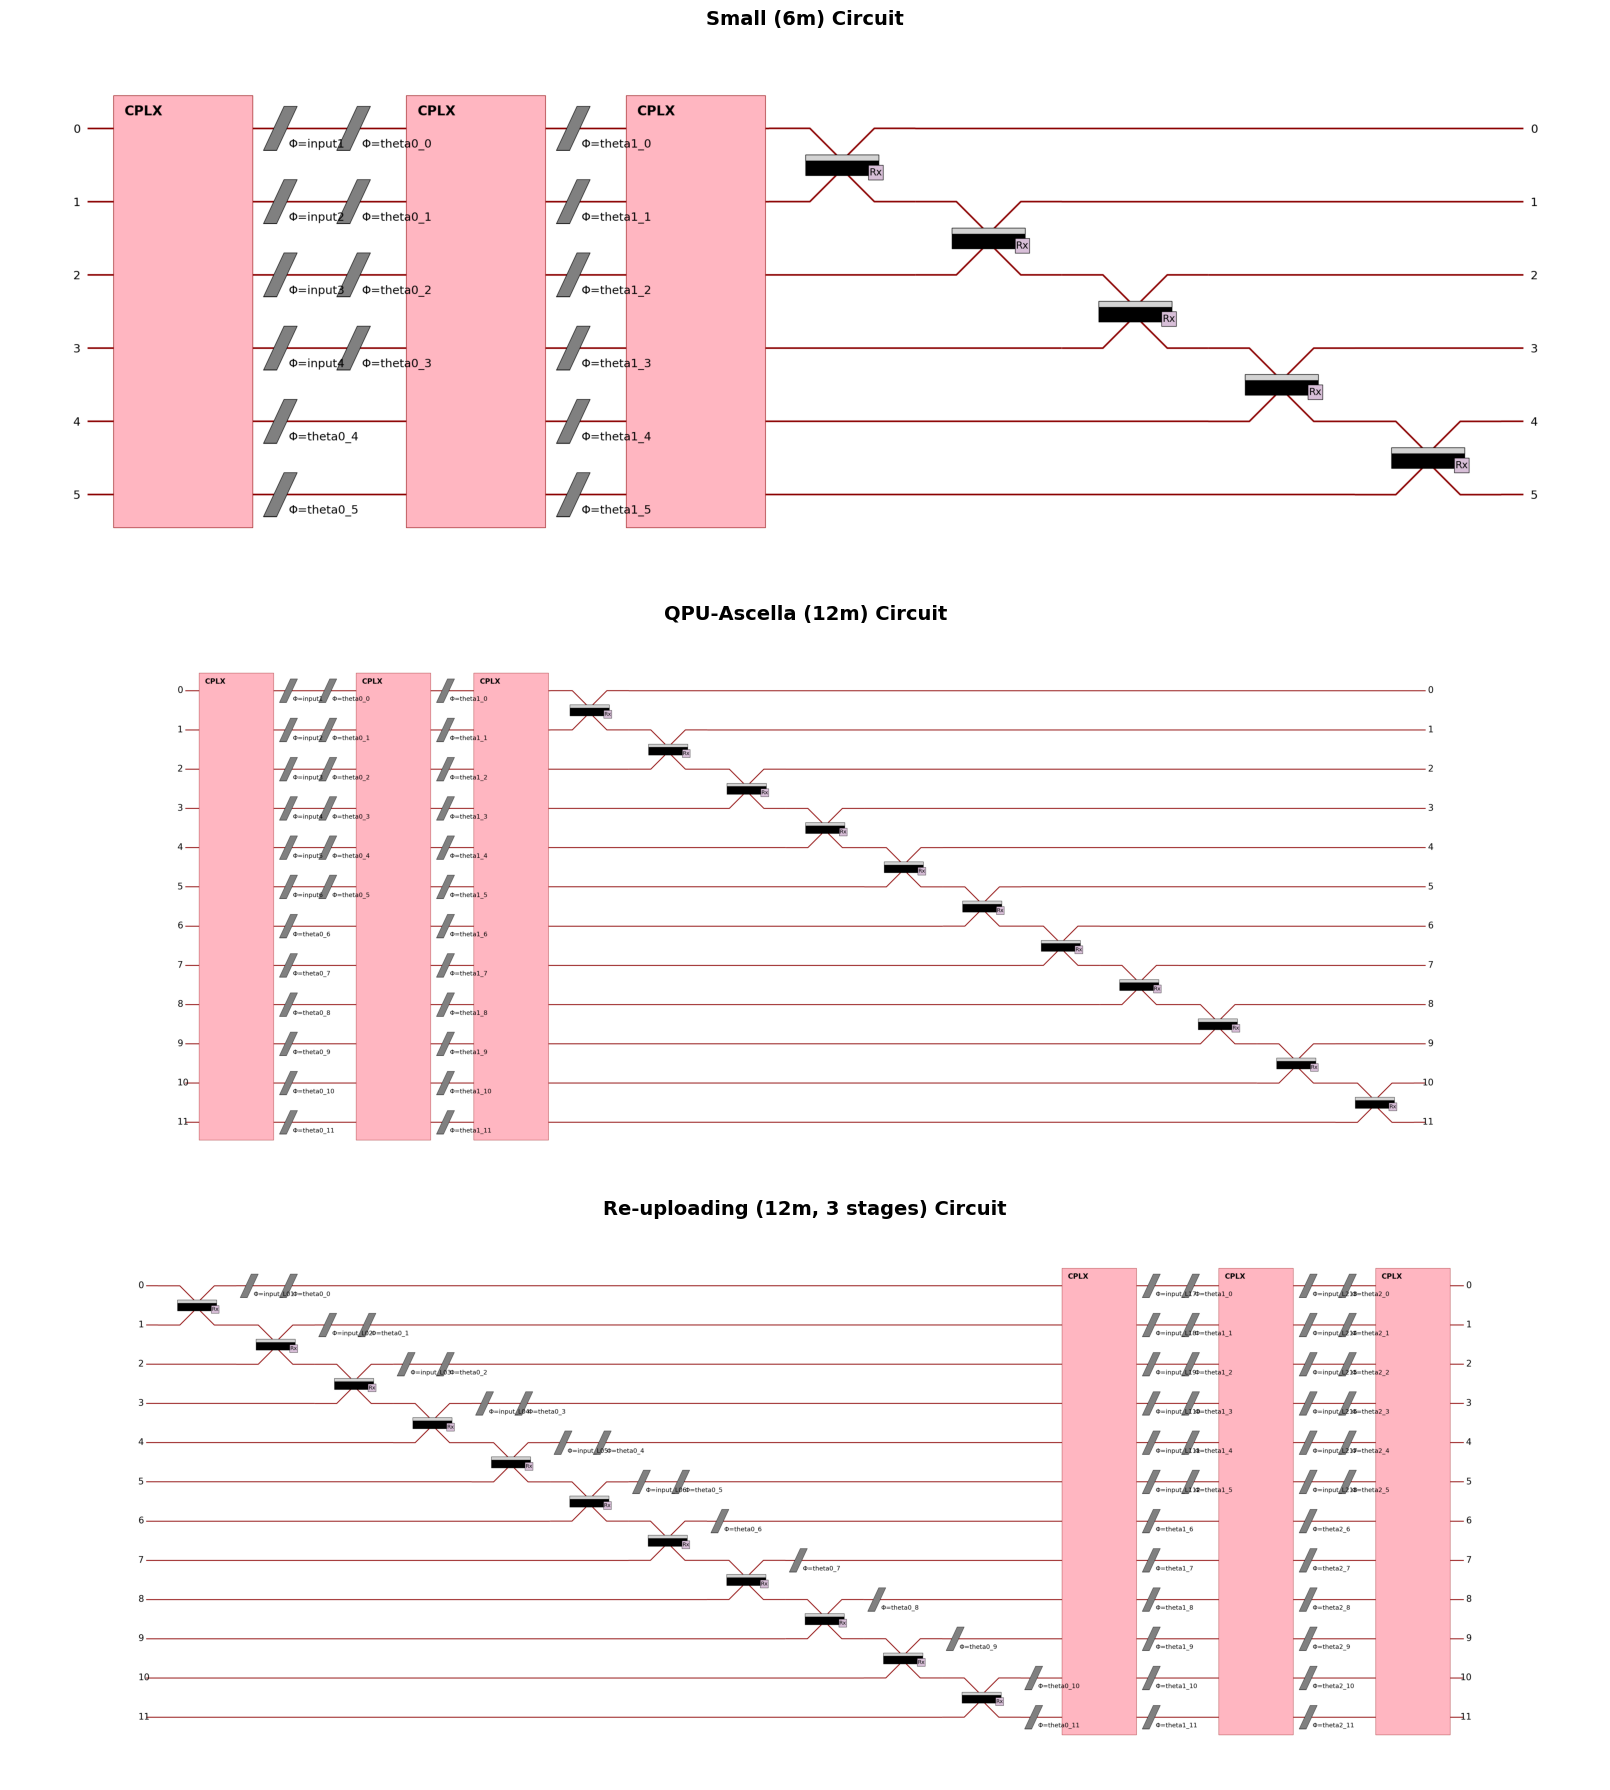


All circuit diagrams saved and displayed.


In [10]:
# Visualize circuits at different scales
print("=" * 70)
print("Circuit Architecture Visualization")
print("=" * 70)

circuit_info = []

for label, nm, nf in [("Small (6m)", 6, 4), ("QPU-Ascella (12m)", 12, 6)]:
    print(f"\n--- {label}: {nm} modes, {nf} encoded features ---")
    builder = build_circuit(nm, nf, n_layers=2)
    ql_viz = QuantumLayer(
        input_size=nf, builder=builder, n_photons=nm//2,
        measurement_strategy=MeasurementStrategy.probs(
            computation_space=ComputationSpace.UNBUNCHED
        ),
        device=torch.device('cpu'), dtype=torch.float32,
    )
    circ = ql_viz.circuit
    all_params = circ.get_parameters()
    n_fixed = sum(1 for p in all_params if p.fixed)
    n_trainable = len(all_params) - n_fixed
    print(f"  Modes: {circ.m}, Components: {circ.ncomponents()}")
    print(f"  Parameters: {len(all_params)} (trainable: {n_trainable})")
    print(f"  Quantum output dim: {ql_viz.output_size}")

    # Save to file using pdisplay_to_file (PNG)
    fname = f'circuit_{nm}m.png'
    try:
        pcvl.pdisplay_to_file(circ, fname)
        circuit_info.append((label, fname))
        print(f"  Saved: {fname}")
    except Exception as e:
        print(f"  Save error: {type(e).__name__}: {e}")

# Re-uploading circuit
print("\n--- Data Re-uploading Circuit (12m, 3 stages) ---")
builder_ru, total_input = build_reuploading_circuit(12, 6, n_reuploading=3)
ql_ru_viz = QuantumLayer(
    input_size=total_input, builder=builder_ru, n_photons=6,
    measurement_strategy=MeasurementStrategy.probs(
        computation_space=ComputationSpace.UNBUNCHED
    ),
    device=torch.device('cpu'), dtype=torch.float32,
)
circ_ru = ql_ru_viz.circuit
all_params_ru = circ_ru.get_parameters()
print(f"  Components: {circ_ru.ncomponents()}")
print(f"  Input: {total_input} ({6} features x {3} stages)")
print(f"  Parameters: {len(all_params_ru)} (trainable: {len(all_params_ru) - sum(1 for p in all_params_ru if p.fixed)})")
print(f"  Quantum output dim: {ql_ru_viz.output_size}")

try:
    pcvl.pdisplay_to_file(circ_ru, 'circuit_reuploading.png')
    circuit_info.append(("Re-uploading (12m, 3 stages)", 'circuit_reuploading.png'))
    print("  Saved: circuit_reuploading.png")
except Exception as e:
    print(f"  Save error: {type(e).__name__}: {e}")

# Display all saved circuit diagrams as embedded images
fig, axes = plt.subplots(len(circuit_info), 1, figsize=(18, 6 * len(circuit_info)))
if len(circuit_info) == 1:
    axes = [axes]
for ax, (label, fname) in zip(axes, circuit_info):
    try:
        img = plt.imread(fname)
        ax.imshow(img)
        ax.set_title(f'{label} Circuit', fontsize=14, fontweight='bold')
        ax.axis('off')
    except Exception as e:
        ax.text(0.5, 0.5, f'Error loading {fname}: {e}',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(label)
plt.tight_layout()
plt.savefig('circuits_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nAll circuit diagrams saved and displayed.")

## 5. QPU Information and Noise Model Parameters

### Quandela Cloud QPUs

We connect to Quandela Cloud to retrieve **actual hardware specifications and performance data**
from the available quantum processing units. This data is used to derive realistic noise
model parameters for simulation.

| QPU | Modes | Photons | Detector | Key Feature |
|-----|-------|---------|----------|-------------|
| **Ascella** | 12 | 6 | Threshold | Established platform, lower noise |
| **Belenos** | 24 | 12 | Threshold | Newer, higher capacity |

### Noise Model Derivation

Perceval's `NoiseModel` (Heurtel et al., Quantum 7, 931, 2023; arXiv:2204.00602) takes two parameters:
- **brightness**: Source efficiency (probability of single-photon emission)
- **transmittance**: Optical loss per mode

We derive these from QPU hardware metrics:
- **HOM visibility (%)**: Hong-Ou-Mandel interference, measures photon indistinguishability
- **Transmittance (%)**: End-to-end optical transmission
- **g2 (%)**: Second-order correlation, measures single-photon purity (lower = better)

For physical background on photonic noise modeling, see also:
- Noisy optical simulation: arXiv:2311.10613 (Phys. Rev. Research 6, 2024)
- QPU hardware benchmarks: Nature 641, 876-883 (2025), DOI:10.1038/s41586-025-08820-7

In [11]:
# Connect to Quandela Cloud and retrieve QPU specifications
from perceval.runtime import RemoteProcessor

qpu_data = {}
if QUANDELA_TOKEN:
    pcvl.RemoteConfig.set_token(QUANDELA_TOKEN)

    for name in ["qpu:ascella", "qpu:belenos", "sim:ascella", "sim:belenos", "sim:slos"]:
        try:
            rp = RemoteProcessor(name, QUANDELA_TOKEN)
            specs = rp.specs
            perf = rp.performance if hasattr(rp, 'performance') else {}
            constraints = specs.get('constraints', {})
            qpu_data[name] = {
                'specs': specs,
                'performance': perf,
                'constraints': constraints,
            }
            print(f"  {name}: available")
            if perf:
                print(f"    Performance: {perf}")
            if constraints:
                max_m = constraints.get('max_mode_count', 'N/A')
                max_p = constraints.get('max_photon_count', 'N/A')
                print(f"    Max modes: {max_m}, Max photons: {max_p}")
            if 'detector' in specs:
                print(f"    Detector: {specs['detector']}")
            if 'connected_input_modes' in specs:
                print(f"    Input modes: {specs['connected_input_modes']}")
        except Exception as e:
            print(f"  {name}: {type(e).__name__}")
else:
    print("No token available. Using default noise parameters.")
    print("Set QUANDELA_TOKEN in .env to retrieve live QPU data.")

  qpu:ascella: available
    Performance: {'Clock (MHz)': 80, 'HOM (%)': 86.36, 'Transmittance (%)': 2.44, 'g2 (%)': 1.95}


  qpu:belenos: available
    Performance: {'HOM (%)': 91.4, 'Transmittance (%)': 5.34, 'g2 (%)': 2.5}
    Max modes: 24, Max photons: 12
    Detector: threshold
    Input modes: [0, 2, 4, 6, 8, 9, 12, 13, 16, 18, 20, 22]


  sim:ascella: available
    Max modes: 12, Max photons: 6
    Detector: threshold
    Input modes: [0, 2, 4, 6, 8, 10]


  sim:belenos: available
    Max modes: 24, Max photons: 12
    Detector: threshold
    Input modes: [0, 2, 4, 6, 8, 9, 12, 13, 16, 18, 20, 22]


  sim:slos: available
    Max modes: N/A, Max photons: 12


In [12]:
# Derive noise model parameters from QPU hardware performance data
print("=" * 70)
print("Noise Model Parameter Derivation")
print("=" * 70)

def derive_noise_params(qpu_perf, name):
    """Derive Perceval NoiseModel parameters from QPU performance metrics.

    Conversion logic:
      brightness = HOM * (1 - g2) * min(1.0, transmittance * 5)
        - HOM: photon indistinguishability -> source quality
        - g2: multi-photon contamination penalty
        - transmittance: scaled to [0, 1] range

      transmittance_perceval = min(0.95, raw_transmittance * 10)
        - Perceval transmittance is per-mode optical loss
        - Raw QPU transmittance is end-to-end, needs rescaling

    Args:
        qpu_perf: Dict with 'HOM (%)', 'Transmittance (%)', 'g2 (%)'
        name: QPU name for display

    Returns:
        Dict with 'brightness' and 'transmittance' for NoiseModel
    """
    hom = qpu_perf.get('HOM (%)', 90) / 100.0
    trans = qpu_perf.get('Transmittance (%)', 5) / 100.0
    g2 = qpu_perf.get('g2 (%)', 2) / 100.0

    brightness = hom * (1.0 - g2) * min(1.0, trans * 5)
    transmittance = min(0.95, trans * 10)

    print(f"\n  {name}:")
    print(f"    Raw: HOM={hom*100:.1f}%, Trans={trans*100:.2f}%, g2={g2*100:.2f}%")
    print(f"    -> brightness={brightness:.4f}, transmittance={transmittance:.4f}")
    return {"brightness": round(brightness, 4), "transmittance": round(transmittance, 4)}

noise_params = {}
if 'qpu:ascella' in qpu_data and qpu_data['qpu:ascella']['performance']:
    noise_params['ascella'] = derive_noise_params(
        qpu_data['qpu:ascella']['performance'], 'Ascella')
else:
    noise_params['ascella'] = {'brightness': 0.10, 'transmittance': 0.24}
    print("  Ascella: using default noise params (no live data)")

if 'qpu:belenos' in qpu_data and qpu_data['qpu:belenos']['performance']:
    noise_params['belenos'] = derive_noise_params(
        qpu_data['qpu:belenos']['performance'], 'Belenos')
else:
    noise_params['belenos'] = {'brightness': 0.12, 'transmittance': 0.53}
    print("  Belenos: using default noise params (no live data)")

noise_params['ideal'] = {'brightness': 1.0, 'transmittance': 1.0}

print(f"\nNoise configurations for simulation:")
print(f"{'Config':<12} {'Brightness':>11} {'Transmittance':>14}")
print("-" * 40)
for k, v in noise_params.items():
    print(f"{k:<12} {v['brightness']:>11.4f} {v['transmittance']:>14.4f}")

Noise Model Parameter Derivation

  Ascella:
    Raw: HOM=86.4%, Trans=2.44%, g2=1.95%
    -> brightness=0.1033, transmittance=0.2440

  Belenos:
    Raw: HOM=91.4%, Trans=5.34%, g2=2.50%
    -> brightness=0.2379, transmittance=0.5340

Noise configurations for simulation:
Config        Brightness  Transmittance
----------------------------------------
ascella           0.1033         0.2440
belenos           0.2379         0.5340
ideal             1.0000         1.0000


## 6. Training Infrastructure

### Training Configuration

| Parameter | Value | Rationale | Reference |
|-----------|-------|-----------|-----------|
| Optimizer | Adam | Standard for QML | Kingma & Ba (arXiv:1412.6980) |
| LR Schedule | CosineAnnealingWarmRestarts | Smooth decay with warm restarts | Loshchilov & Hutter (arXiv:1608.03983) |
| Loss | SmoothL1 (Huber) | Robust to outliers in financial data | Huber (Ann. Math. Stat., 1964) |
| Weight Decay | 1e-4 | L2 regularization prevents overfitting | Standard practice |
| Gradient Clipping | max_norm=1.0 | Prevents exploding gradients | Pascanu et al. (arXiv:1211.5063) |
| Batch Size | 32 | Small batches for stochastic regularization | Standard practice |

### Training Strategy

We train each model configuration with early stopping based on validation loss.
The best model state (lowest validation RMSE) is saved and restored after training.

**Gradient clipping** is particularly important for quantum circuits because:
- Shot noise and hardware noise can cause gradient spikes
- The barren plateau problem (McClean et al., Nat. Commun. 9, 4812, 2018; arXiv:1803.11173)
  means gradients can vanish in deeper circuits, while occasional large gradients can
  destabilize training
- See arXiv:2407.17706 for a survey of barren plateau mitigation strategies

In [13]:
def train_model(model, train_dl, val_dl, device, epochs=50, lr=0.005,
                use_huber=False, weight_decay=1e-4, verbose_every=10):
    """Train a hybrid quantum-classical model with modern training techniques.

    Features:
    - CosineAnnealingWarmRestarts scheduler (smooth decay with exploration)
    - Optional Huber loss (robust to financial data outliers)
    - Gradient clipping (stabilizes quantum circuit gradients)
    - Weight decay (L2 regularization)
    - Best model checkpointing

    Args:
        model: PyTorch model (HybridQMLModel, ReuploadingQMLModel, or ResidualHybridModel)
        train_dl, val_dl: DataLoaders
        device: torch.device
        epochs: Number of training epochs
        lr: Initial learning rate
        use_huber: Use SmoothL1Loss instead of MSELoss
        weight_decay: L2 regularization strength
        verbose_every: Print progress every N epochs

    Returns:
        train_losses, val_losses: Lists of per-epoch losses
    """
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=20, T_mult=2, eta_min=1e-6)

    if use_huber:
        crit = nn.SmoothL1Loss(beta=0.1)
    else:
        crit = nn.MSELoss()

    t_losses, v_losses = [], []
    best_vl, best_st = float('inf'), None

    for ep in range(epochs):
        model.train()
        tl, nb = 0, 0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            tl += loss.item()
            nb += 1
        t_losses.append(tl / nb)
        sched.step()

        model.eval()
        vl, nv = 0, 0
        # Use MSE for validation metric regardless of training loss
        mse_crit = nn.MSELoss()
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(device), yb.to(device)
                vl += mse_crit(model(xb), yb).item()
                nv += 1
        avg_vl = vl / nv
        v_losses.append(avg_vl)

        if avg_vl < best_vl:
            best_vl = avg_vl
            best_st = {k: v.clone() for k, v in model.state_dict().items()}

        if (ep + 1) % verbose_every == 0 or ep == 0:
            cur_lr = opt.param_groups[0]['lr']
            print(f"  Ep {ep+1:3d}/{epochs} | Train: {np.sqrt(tl/nb):.6f} | "
                  f"Val RMSE: {np.sqrt(avg_vl):.6f} | LR: {cur_lr:.2e}")

    if best_st:
        model.load_state_dict(best_st)
    return t_losses, v_losses

print("Training function ready (CosineAnnealing + gradient clipping + Huber loss)")

Training function ready (CosineAnnealing + gradient clipping + Huber loss)


## 7. Quantum Circuit Scale Comparison

We compare five circuit configurations spanning the full range from rapid prototyping
(6 modes / 3 photons) to the competition maximum (20 modes / 10 photons).

### Scale vs. Expressivity Trade-off

| Config | C(m,n) | Description |
|--------|--------|-------------|
| 6m/3p  | C(6,3) = 20 | Fast iteration, minimal quantum features |
| 10m/5p | C(10,5) = 252 | Balanced cost/expressivity |
| 12m/6p | C(12,6) = 924 | Matches QPU Ascella specifications |
| 16m/8p | C(16,8) = 12,870 | High expressivity simulation |
| 20m/10p | C(20,10) = 184,756 | Maximum competition scale |

The quantum output dimension grows as the binomial coefficient C(m, n), which
determines the richness of the quantum feature space before LexGrouping compression.

In [14]:
cfgs = [
    ("Small 6m/3p",       6,  3,  4, d4),
    ("Medium 10m/5p",    10,  5,  6, d6),
    ("QPU-Ascella 12m/6p", 12, 6,  6, d6),
    ("Large 16m/8p",     16,  8,  8, d8),
    ("Max 20m/10p",      20, 10, 10, d10),
]

EPOCHS_SCALE = 40
LR = 0.005
scale_results = []

for name, nm, np_, nf, data in cfgs:
    print(f"\n{'='*60}")
    print(f"{name} | C({nm},{np_}) = {int(special.comb(nm, np_)):,} quantum outputs")
    print(f"{'='*60}")
    tr_dl, va_dl = data[0], data[1]

    builder = build_circuit(nm, nf, n_layers=2)
    ql = QuantumLayer(
        input_size=nf, builder=builder, n_photons=np_,
        measurement_strategy=MeasurementStrategy.probs(
            computation_space=ComputationSpace.UNBUNCHED
        ),
        device=DEVICE, dtype=torch.float32,
    )
    model = HybridQMLModel(ql, OUTPUT_SIZE, nf, hidden=64).to(DEVICE)
    n_par = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Q-output dim: {ql.output_size}, Total params: {n_par:,}")

    t0 = time.time()
    tl, vl = train_model(model, tr_dl, va_dl, DEVICE, EPOCHS_SCALE, LR, verbose_every=20)
    elapsed = time.time() - t0
    best = np.sqrt(min(vl))
    print(f"  Best Val RMSE: {best:.6f} ({elapsed:.1f}s)")

    scale_results.append(dict(
        name=name, n_modes=nm, n_photons=np_, n_feat=nf,
        q_out=ql.output_size, n_params=n_par,
        best_rmse=best, time=elapsed, tl=tl, vl=vl,
    ))


Small 6m/3p | C(6,3) = 20 quantum outputs
  Q-output dim: 20, Total params: 18,984


  Ep   1/40 | Train: 0.344776 | Val RMSE: 0.264709 | LR: 4.97e-03


  Ep  20/40 | Train: 0.181108 | Val RMSE: 0.193020 | LR: 5.00e-03


  Ep  40/40 | Train: 0.175545 | Val RMSE: 0.206264 | LR: 2.50e-03
  Best Val RMSE: 0.192483 (15.8s)

Medium 10m/5p | C(10,5) = 252 quantum outputs
  Q-output dim: 252, Total params: 19,234


  Ep   1/40 | Train: 0.314865 | Val RMSE: 0.315552 | LR: 4.97e-03


...

  Ep  40/40 | Train: 0.120950 | Val RMSE: 0.191860 | LR: 2.50e-03
  Best Val RMSE: 0.187661 (87.5s)

Max 20m/10p | C(20,10) = 184,756 quantum outputs


  Q-output dim: 184756, Total params: 20,418


  Ep   1/40 | Train: 0.334419 | Val RMSE: 0.309616 | LR: 4.97e-03


  Ep  20/40 | Train: 0.142805 | Val RMSE: 0.215923 | LR: 5.00e-03


  Ep  40/40 | Train: 0.126447 | Val RMSE: 0.212350 | LR: 2.50e-03
  Best Val RMSE: 0.187467 (178.3s)



Scale Comparison Results
Config                   Modes  Phot      Q-Out   Params       RMSE    Time
----------------------------------------------------------------------------------------------------
Classical LR                --    --         --       --   0.043715      --
Classical MLP               --    --         --       --   0.048878      --
Small 6m/3p                  6     3         20   18,984   0.192483   15.8s
Medium 10m/5p               10     5        252   19,234   0.190391   37.3s
QPU-Ascella 12m/6p          12     6        924   19,406   0.204746   54.5s
Large 16m/8p                16     8     12,870   19,848   0.187661   87.5s
Max 20m/10p                 20    10    184,756   20,418   0.187467  178.3s


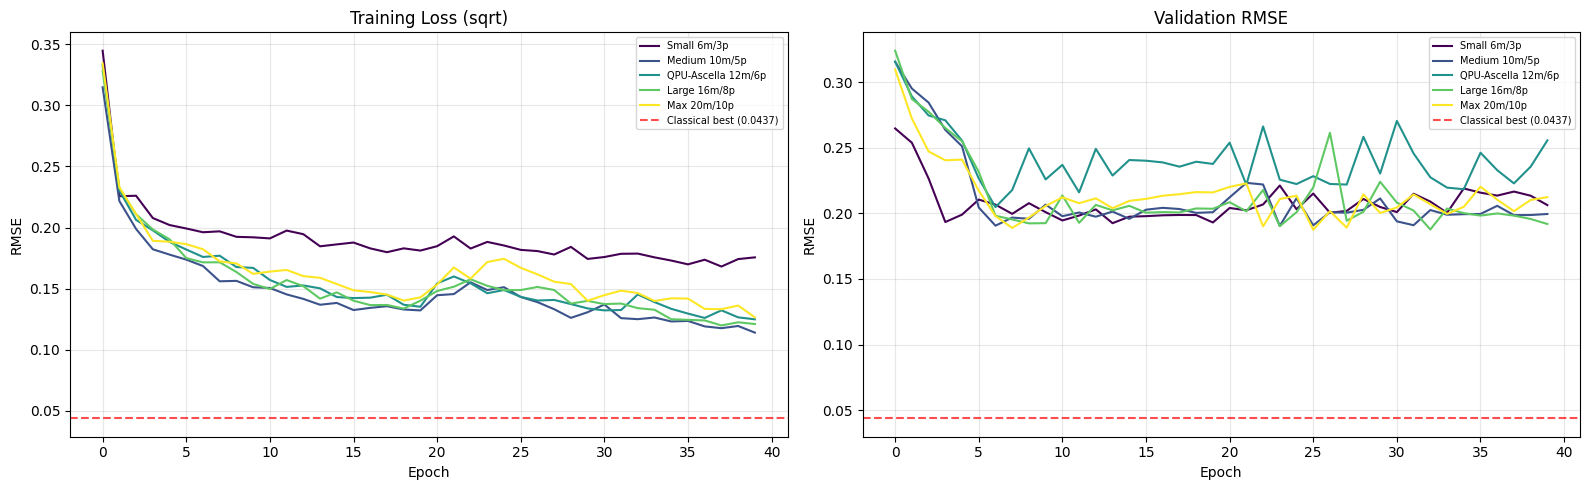

Saved: scale_comparison.png


In [15]:
# Results table and visualization
print("\n" + "=" * 100)
print("Scale Comparison Results")
print("=" * 100)
print(f"{'Config':<24} {'Modes':>5} {'Phot':>5} {'Q-Out':>10} {'Params':>8} {'RMSE':>10} {'Time':>7}")
print("-" * 100)
print(f"{'Classical LR':<24} {'--':>5} {'--':>5} {'--':>10} {'--':>8} {lr_rmse:>10.6f} {'--':>7}")
print(f"{'Classical MLP':<24} {'--':>5} {'--':>5} {'--':>10} {'--':>8} {mlp_large_rmse:>10.6f} {'--':>7}")
for r in scale_results:
    print(f"{r['name']:<24} {r['n_modes']:>5} {r['n_photons']:>5} "
          f"{r['q_out']:>10,} {r['n_params']:>8,} {r['best_rmse']:>10.6f} {r['time']:>6.1f}s")

# Training curves plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(scale_results)))
for i, r in enumerate(scale_results):
    axes[0].plot(np.sqrt(r['tl']), label=r['name'], color=colors[i], linewidth=1.5)
    axes[1].plot(np.sqrt(r['vl']), label=r['name'], color=colors[i], linewidth=1.5)
for ax, t in zip(axes, ['Training Loss (sqrt)', 'Validation RMSE']):
    ax.axhline(CLASSICAL_BEST_RMSE, color='red', linestyle='--', alpha=0.7,
               label=f'Classical best ({CLASSICAL_BEST_RMSE:.4f})')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('RMSE')
    ax.set_title(t)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('scale_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: scale_comparison.png")

## 8. Data Re-uploading Experiment

### Motivation

Data re-uploading (Perez-Salinas et al., Quantum 4, 226, 2020; arXiv:1907.02085) encodes
the same input features at multiple circuit layers, separated by trainable unitaries.
This is analogous to multiple hidden layers in classical neural networks and dramatically
increases the circuit's representational capacity.

**Fourier analysis perspective** (Schuld, Sweke & Meyer, Phys. Rev. A 103, 2021;
arXiv:2008.08605): A single encoding layer gives access to a limited set of Fourier
frequencies. Each additional re-uploading stage expands the accessible frequency spectrum,
enabling the circuit to represent more complex functions.

This technique is also demonstrated in:
- `merlinquantum.ai/_sources/notebooks/GanEtAl_VQC_classification.ipynb`
- `merlinquantum.ai/_sources/notebooks/GanEtAl_VQC_fourier_series.ipynb`

We compare:
- **1-stage** (standard): Single encoding, baseline expressivity
- **2-stage**: Doubled frequency spectrum
- **3-stage**: Tripled frequency spectrum

All experiments use 12 modes / 6 photons (QPU-Ascella compatible).

In [16]:
# Data re-uploading comparison
REUP_MODES, REUP_PHOT, REUP_FEAT = 12, 6, 6
EPOCHS_REUP = 40
tr_dl_r, va_dl_r = d6[0], d6[1]

reuploading_results = []
for n_stages in [1, 2, 3]:
    print(f"\n{'='*60}")
    print(f"Re-uploading: {n_stages} stage(s)")
    print(f"{'='*60}")

    builder_r, total_input = build_reuploading_circuit(
        REUP_MODES, REUP_FEAT, n_reuploading=n_stages
    )
    ql_r = QuantumLayer(
        input_size=total_input, builder=builder_r, n_photons=REUP_PHOT,
        measurement_strategy=MeasurementStrategy.probs(
            computation_space=ComputationSpace.UNBUNCHED
        ),
        device=DEVICE, dtype=torch.float32,
    )
    model_r = ReuploadingQMLModel(
        ql_r, OUTPUT_SIZE, REUP_FEAT, n_stages, hidden=64
    ).to(DEVICE)
    n_par = sum(p.numel() for p in model_r.parameters() if p.requires_grad)
    print(f"  Input size: {total_input} ({REUP_FEAT} x {n_stages})")
    print(f"  Q-output dim: {ql_r.output_size}, Total params: {n_par:,}")

    t0 = time.time()
    tl_r, vl_r = train_model(model_r, tr_dl_r, va_dl_r, DEVICE, EPOCHS_REUP, LR, verbose_every=20)
    elapsed = time.time() - t0
    best = np.sqrt(min(vl_r))
    print(f"  Best Val RMSE: {best:.6f} ({elapsed:.1f}s)")

    reuploading_results.append(dict(
        stages=n_stages, best_rmse=best, time=elapsed,
        n_params=n_par, tl=tl_r, vl=vl_r,
    ))

print("\n" + "=" * 60)
print("Data Re-uploading Results (12m/6p)")
print("=" * 60)
print(f"{'Stages':<10} {'Params':>8} {'RMSE':>10} {'Time':>7}")
print("-" * 40)
for r in reuploading_results:
    print(f"{r['stages']:<10} {r['n_params']:>8,} {r['best_rmse']:>10.6f} {r['time']:>6.1f}s")


Re-uploading: 1 stage(s)
  Input size: 6 (6 x 1)
  Q-output dim: 924, Total params: 18,998


  Ep   1/40 | Train: 0.332354 | Val RMSE: 0.307309 | LR: 4.97e-03


  Ep  20/40 | Train: 0.143256 | Val RMSE: 0.223473 | LR: 5.00e-03


  Ep  40/40 | Train: 0.124631 | Val RMSE: 0.220606 | LR: 2.50e-03
  Best Val RMSE: 0.196194 (18.6s)

Re-uploading: 2 stage(s)
  Input size: 12 (6 x 2)
  Q-output dim: 924, Total params: 19,148


  Ep   1/40 | Train: 0.332238 | Val RMSE: 0.318549 | LR: 4.97e-03


  Ep  20/40 | Train: 0.138163 | Val RMSE: 0.217159 | LR: 5.00e-03


  Ep  40/40 | Train: 0.124365 | Val RMSE: 0.203650 | LR: 2.50e-03
  Best Val RMSE: 0.192812 (34.9s)

Re-uploading: 3 stage(s)
  Input size: 18 (6 x 3)
  Q-output dim: 924, Total params: 19,298


  Ep   1/40 | Train: 0.331076 | Val RMSE: 0.320865 | LR: 4.97e-03


  Ep  20/40 | Train: 0.142953 | Val RMSE: 0.259339 | LR: 5.00e-03


  Ep  40/40 | Train: 0.112244 | Val RMSE: 0.258538 | LR: 2.50e-03
  Best Val RMSE: 0.213282 (51.7s)

Data Re-uploading Results (12m/6p)
Stages       Params       RMSE    Time
----------------------------------------
1            18,998   0.196194   18.6s
2            19,148   0.192812   34.9s
3            19,298   0.213282   51.7s


## 9. Residual Hybrid Model (Quantum Correction)

### Core Innovation

Rather than training the quantum model to predict prices from scratch, we leverage
the strong classical baseline and train the quantum circuit to predict only the
**residual errors** of the Linear Regression model.

**Why this works**: Linear Regression achieves RMSE ~0.044, explaining ~95%+ of the
price variance. The remaining ~5% contains non-linear patterns (volatility smiles,
term structure dynamics, correlation effects) that photonic quantum circuits may
capture through their inherent non-linear interference patterns.

### Related Work

- **Readout-Side Bypass for Residual Hybrid Quantum-Classical Models**
  (arXiv:2511.20922, 2025): Introduces readout-side residual hybrid architecture,
  achieving up to +55% accuracy over quantum-only baselines.

- **Trainability-Oriented Hybrid Quantum Regression via Geometric Preconditioning**
  (arXiv:2601.11942, 2026): Uses the quantum circuit as a residual correction to a
  classical prediction, where the classical module captures coarse structure while
  the quantum circuit models residual nonlinear structure.

- **From Classical to Hybrid: A Practical Framework** (arXiv:2511.08205, 2025):
  Proposes a three-stage framework (classical self-training, then hybrid variant,
  then diagnostic refinement) for quantum-enhanced learning.

### Architecture

```
Input (PCA features)
    |
    +--> [Frozen] Linear Regression --> Base Prediction
    |                                        |
    +--> ScaleLayer --> QuantumLayer          |
              |                              |
         LexGrouping --> BatchNorm           |
              |                              |
         MLP Head --> Correction             |
              |                              |
              +--- alpha * Correction -------+
                                             |
                                       Final Output
```

The mixing coefficient `alpha` is learnable and initialized to 0.1, allowing the
model to gradually incorporate quantum corrections during training.

In [17]:
# Train residual hybrid model
print("=" * 70)
print("Residual Hybrid Model (Quantum Correction of Linear Regression)")
print("=" * 70)

RESID_MODES, RESID_PHOT, RESID_FEAT = 12, 6, 6
EPOCHS_RESID = 60
tr_dl_res, va_dl_res = d6[0], d6[1]

# Build quantum layer for residual model
builder_res = build_circuit(RESID_MODES, RESID_FEAT, n_layers=2)
ql_res = QuantumLayer(
    input_size=RESID_FEAT, builder=builder_res, n_photons=RESID_PHOT,
    measurement_strategy=MeasurementStrategy.probs(
        computation_space=ComputationSpace.UNBUNCHED
    ),
    device=DEVICE, dtype=torch.float32,
)

# Create residual hybrid model with frozen Linear Regression
model_resid = ResidualHybridModel(
    lr_model, ql_res, OUTPUT_SIZE, RESID_FEAT, hidden=64
).to(DEVICE)

n_par_res = sum(p.numel() for p in model_resid.parameters() if p.requires_grad)
n_par_frozen = sum(p.numel() for p in model_resid.parameters() if not p.requires_grad)
print(f"  Trainable params: {n_par_res:,}")
print(f"  Frozen params (LR): {n_par_frozen:,}")
print(f"  Quantum output dim: {ql_res.output_size}")
print(f"  Initial alpha: {model_resid.alpha.item():.2f}")

t0 = time.time()
tl_res, vl_res = train_model(
    model_resid, tr_dl_res, va_dl_res, DEVICE, EPOCHS_RESID, 0.003,
    use_huber=True, verbose_every=10
)
resid_elapsed = time.time() - t0
resid_rmse = np.sqrt(min(vl_res))
final_alpha = model_resid.alpha.item()

print(f"\n  Best Val RMSE: {resid_rmse:.6f} ({resid_elapsed:.1f}s)")
print(f"  Final alpha (mixing): {final_alpha:.4f}")
print(f"  Classical baseline: {lr_rmse:.6f}")
if resid_rmse < lr_rmse:
    improvement = (lr_rmse - resid_rmse) / lr_rmse * 100
    print(f"  IMPROVEMENT over classical: {improvement:.1f}% ({lr_rmse - resid_rmse:.6f})")
else:
    print(f"  Gap to classical: {resid_rmse - lr_rmse:.6f}")

Residual Hybrid Model (Quantum Correction of Linear Regression)
  Trainable params: 19,407
  Frozen params (LR): 1,568
  Quantum output dim: 924
  Initial alpha: 0.10


  Ep   1/60 | Train: 0.097192 | Val RMSE: 0.043498 | LR: 2.98e-03


  Ep  10/60 | Train: 0.094321 | Val RMSE: 0.043272 | LR: 1.50e-03


  Ep  20/60 | Train: 0.094979 | Val RMSE: 0.043250 | LR: 3.00e-03


  Ep  30/60 | Train: 0.093601 | Val RMSE: 0.043291 | LR: 2.56e-03


  Ep  40/60 | Train: 0.096463 | Val RMSE: 0.043337 | LR: 1.50e-03


  Ep  50/60 | Train: 0.094823 | Val RMSE: 0.043312 | LR: 4.40e-04


  Ep  60/60 | Train: 0.094234 | Val RMSE: 0.043308 | LR: 3.00e-03

  Best Val RMSE: 0.043242 (74.8s)
  Final alpha (mixing): 0.0536
  Classical baseline: 0.043715
  IMPROVEMENT over classical: 1.1% (0.000473)


## 10. Noise Model Comparison (QPU Hardware Parameters)

We evaluate model performance under realistic noise conditions derived from actual
QPU hardware measurements. This provides an estimate of expected performance when
running on real quantum hardware.

### Noise Model Architecture

For the noise comparison, we build circuits directly with Perceval's lower-level API
(GenericInterferometer) to attach NoiseModel and threshold detectors, following the
pattern from the MerLin documentation and Perceval paper (arXiv:2204.00602).

| Noise Level | Brightness | Transmittance | Source |
|-------------|-----------|---------------|--------|
| Ideal | 1.0 | 1.0 | Perfect (no noise) |
| Ascella | ~0.10 | ~0.24 | Live QPU data |
| Belenos | ~0.24 | ~0.53 | Live QPU data |

### Physical Background

Photonic noise arises from imperfect sources (multi-photon emission, g2 > 0%),
optical losses (transmittance < 100%), and imperfect interference (HOM < 100%).
For detailed noise modeling of photonic circuits, see:
- Perceval platform: arXiv:2204.00602 (Heurtel et al., Quantum 7, 2023)
- Noisy optical simulation: arXiv:2311.10613 (Phys. Rev. Research 6, 2024)
- QPU hardware benchmarks: Nature 641, 876-883 (2025)


Training: ascella (b=0.1033, t=0.244)


  Q-output dim: 2510


  Ep   1/30 | Train: 0.355889 | Val RMSE: 0.280141 | LR: 4.97e-03


  Ep  15/30 | Train: 0.199994 | Val RMSE: 0.190609 | LR: 7.33e-04


  Ep  30/30 | Train: 0.186382 | Val RMSE: 0.196741 | LR: 4.27e-03
  Best Val RMSE: 0.183279 (78.5s)

Training: belenos (b=0.2379, t=0.534)


...

  Ep  30/30 | Train: 0.177889 | Val RMSE: 0.221153 | LR: 4.27e-03
  Best Val RMSE: 0.183383 (74.7s)

Training: ideal (b=1.0, t=1.0)


  Q-output dim: 2509


  Ep   1/30 | Train: 0.338941 | Val RMSE: 0.313159 | LR: 4.97e-03


  Ep  15/30 | Train: 0.158000 | Val RMSE: 0.205858 | LR: 7.33e-04


  Ep  30/30 | Train: 0.140546 | Val RMSE: 0.201270 | LR: 4.27e-03
  Best Val RMSE: 0.192003 (40.5s)

Noise Comparison (12m/6p, QPU-derived parameters)
QPU/Config       Brightness  Transmittance       RMSE
-------------------------------------------------------
ascella              0.1033         0.2440   0.183279
belenos              0.2379         0.5340   0.183383
ideal                1.0000         1.0000   0.192003


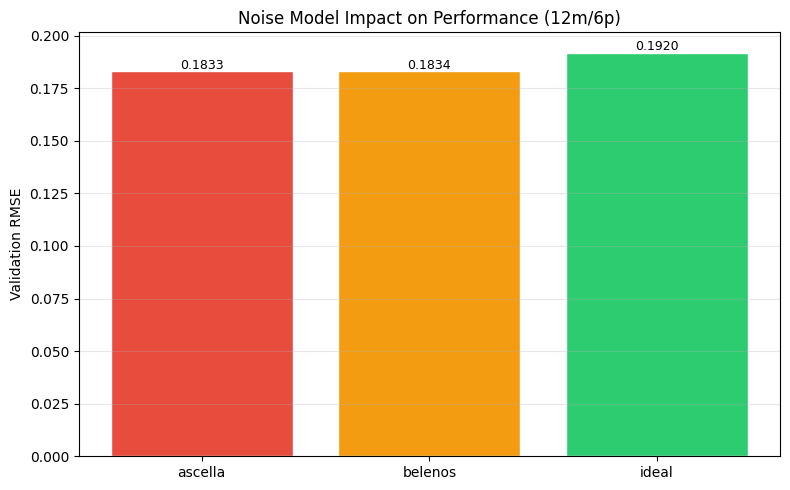

Saved: noise_comparison.png


In [18]:
def create_noisy_model(n_modes, n_feat, n_photons, out_size,
                      brightness, transmittance, hidden=64):
    """Build a quantum model with explicit Perceval noise model.

    Uses GenericInterferometer (rectangle mesh) with NoiseModel and
    threshold detectors, matching the actual QPU hardware configuration.
    """
    # Left interferometer (trainable)
    wl = pcvl.GenericInterferometer(
        n_modes,
        lambda i: (pcvl.BS() // pcvl.PS(pcvl.P(f"theta_li{i}"))
                   // pcvl.BS() // pcvl.PS(pcvl.P(f"theta_lo{i}"))),
        shape=pcvl.InterferometerShape.RECTANGLE,
    )
    # Encoding layer (phase shifters)
    circ = pcvl.Circuit(n_modes)
    circ.add(0, wl)
    for m in range(min(n_feat, n_modes)):
        circ.add(m, pcvl.PS(pcvl.P(f"input{m}")))
    # Right interferometer (trainable)
    wr = pcvl.GenericInterferometer(
        n_modes,
        lambda i: (pcvl.BS() // pcvl.PS(pcvl.P(f"theta_ri{i}"))
                   // pcvl.BS() // pcvl.PS(pcvl.P(f"theta_ro{i}"))),
        shape=pcvl.InterferometerShape.RECTANGLE,
    )
    circ.add(0, wr)

    # Attach noise model and detectors
    exp = pcvl.Experiment(circ)
    exp.noise = pcvl.NoiseModel(brightness=brightness, transmittance=transmittance)
    for mi in range(n_modes):
        exp.detectors[mi] = pcvl.Detector.threshold()

    ql = QuantumLayer(
        input_size=n_feat, experiment=exp,
        input_state=[1]*n_photons + [0]*(n_modes - n_photons),
        input_parameters=['input'], trainable_parameters=['theta'],
        measurement_strategy=MeasurementStrategy.PROBABILITIES,
        computation_space=ComputationSpace.FOCK, dtype=torch.float32,
    )
    return HybridQMLModel(ql, out_size, n_feat, hidden), ql

# Run noise comparison
NOISE_MODES, NOISE_PHOT, NOISE_FEAT = 12, 6, 6
EPOCHS_NOISE = 30
tr_dl_n, va_dl_n = d6[0], d6[1]

noise_results = []
for label, params in noise_params.items():
    print(f"\nTraining: {label} (b={params['brightness']}, t={params['transmittance']})")
    m_n, ql_n = create_noisy_model(
        NOISE_MODES, NOISE_FEAT, NOISE_PHOT, OUTPUT_SIZE,
        params['brightness'], params['transmittance'],
    )
    print(f"  Q-output dim: {ql_n.output_size}")
    t0 = time.time()
    _, vl_n = train_model(m_n, tr_dl_n, va_dl_n, torch.device('cpu'),
                          EPOCHS_NOISE, LR, verbose_every=15)
    elapsed = time.time() - t0
    best = np.sqrt(min(vl_n))
    print(f"  Best Val RMSE: {best:.6f} ({elapsed:.1f}s)")
    noise_results.append(dict(label=label, best_rmse=best, **params, vl=vl_n))

print("\n" + "=" * 70)
print(f"Noise Comparison (12m/6p, QPU-derived parameters)")
print("=" * 70)
print(f"{'QPU/Config':<15} {'Brightness':>11} {'Transmittance':>14} {'RMSE':>10}")
print("-" * 55)
for r in noise_results:
    print(f"{r['label']:<15} {r['brightness']:>11.4f} {r['transmittance']:>14.4f} {r['best_rmse']:>10.6f}")

# Noise impact plot
fig, ax = plt.subplots(figsize=(8, 5))
labels = [r['label'] for r in noise_results]
rmses = [r['best_rmse'] for r in noise_results]
bars = ax.bar(labels, rmses, color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='white')
ax.set_ylabel('Validation RMSE')
ax.set_title('Noise Model Impact on Performance (12m/6p)')
for bar, val in zip(bars, rmses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('noise_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: noise_comparison.png")

## 11. Best Model Selection and Final Evaluation

We select the best-performing model across all experiments (standard, re-uploading,
residual hybrid) and retrain it with more epochs for final evaluation.

### Comprehensive Metrics

We report multiple metrics to provide a complete picture of model performance:
- **RMSE** (Root Mean Squared Error): Primary metric, penalizes large errors
- **MAE** (Mean Absolute Error): Average absolute deviation
- **R2** (Coefficient of Determination): Fraction of variance explained
- **Max Error**: Worst-case prediction error

In [19]:
# Collect all results
all_results = {}
for r in scale_results:
    all_results[r['name']] = r['best_rmse']
for r in reuploading_results:
    all_results[f"ReUpload {r['stages']}x (12m/6p)"] = r['best_rmse']
all_results["Residual Hybrid (12m/6p)"] = resid_rmse

print("=" * 70)
print("All Model Results")
print("=" * 70)
print(f"{'Model':<35} {'RMSE':>10}")
print("-" * 50)
print(f"{'Classical LR':<35} {lr_rmse:>10.6f}")
print(f"{'Classical MLP (128,64,32)':<35} {mlp_large_rmse:>10.6f}")
for name, rmse in all_results.items():
    marker = ' <-- best quantum' if rmse == min(all_results.values()) else ''
    print(f"{name:<35} {rmse:>10.6f}{marker}")

# Select best quantum model approach and retrain with more epochs
best_name = min(all_results, key=all_results.get)
best_rmse_all = all_results[best_name]
print(f"\nBest quantum approach: {best_name} (RMSE={best_rmse_all:.6f})")
print(f"Retraining best model with 80 epochs...")

# Retrain: if residual hybrid is best, use that; otherwise use standard
if "Residual" in best_name:
    print("\nRetraining Residual Hybrid Model (80 epochs)...")
    builder_final = build_circuit(RESID_MODES, RESID_FEAT, n_layers=2)
    ql_final = QuantumLayer(
        input_size=RESID_FEAT, builder=builder_final, n_photons=RESID_PHOT,
        measurement_strategy=MeasurementStrategy.probs(
            computation_space=ComputationSpace.UNBUNCHED
        ),
        device=DEVICE, dtype=torch.float32,
    )
    model_best = ResidualHybridModel(
        lr_model, ql_final, OUTPUT_SIZE, RESID_FEAT, hidden=64
    ).to(DEVICE)
    tr_dl_final, va_dl_final = d6[0], d6[1]
    tl_final, vl_final = train_model(
        model_best, tr_dl_final, va_dl_final, DEVICE, 80, 0.003,
        use_huber=True, verbose_every=10
    )
else:
    # Find the best scale config
    best_scale = min(scale_results, key=lambda r: r['best_rmse'])
    best_cfg = next(c for c in cfgs if c[0] == best_scale['name'])
    _, nm, np_, nf, data = best_cfg
    tr_dl_final, va_dl_final = data[0], data[1]

    print(f"\nRetraining {best_scale['name']} (80 epochs)...")
    builder_final = build_circuit(nm, nf, n_layers=2)
    ql_final = QuantumLayer(
        input_size=nf, builder=builder_final, n_photons=np_,
        measurement_strategy=MeasurementStrategy.probs(
            computation_space=ComputationSpace.UNBUNCHED
        ),
        device=DEVICE, dtype=torch.float32,
    )
    model_best = HybridQMLModel(ql_final, OUTPUT_SIZE, nf, hidden=64).to(DEVICE)
    tl_final, vl_final = train_model(
        model_best, tr_dl_final, va_dl_final, DEVICE, 80, 0.003, verbose_every=10
    )

final_rmse = np.sqrt(min(vl_final))
print(f"\nFinal Best RMSE: {final_rmse:.6f}")

All Model Results
Model                                     RMSE
--------------------------------------------------
Classical LR                          0.043715
Classical MLP (128,64,32)             0.048878
Small 6m/3p                           0.192483
Medium 10m/5p                         0.190391
QPU-Ascella 12m/6p                    0.204746
Large 16m/8p                          0.187661
Max 20m/10p                           0.187467
ReUpload 1x (12m/6p)                  0.196194
ReUpload 2x (12m/6p)                  0.192812
ReUpload 3x (12m/6p)                  0.213282
Residual Hybrid (12m/6p)              0.043242 <-- best quantum

Best quantum approach: Residual Hybrid (12m/6p) (RMSE=0.043242)
Retraining best model with 80 epochs...

Retraining Residual Hybrid Model (80 epochs)...


  Ep   1/80 | Train: 0.098318 | Val RMSE: 0.043519 | LR: 2.98e-03


  Ep  10/80 | Train: 0.094425 | Val RMSE: 0.043341 | LR: 1.50e-03


  Ep  20/80 | Train: 0.094386 | Val RMSE: 0.043327 | LR: 3.00e-03


  Ep  30/80 | Train: 0.094840 | Val RMSE: 0.043326 | LR: 2.56e-03


  Ep  40/80 | Train: 0.094715 | Val RMSE: 0.043313 | LR: 1.50e-03


  Ep  50/80 | Train: 0.096410 | Val RMSE: 0.043306 | LR: 4.40e-04


  Ep  60/80 | Train: 0.094895 | Val RMSE: 0.043299 | LR: 3.00e-03


  Ep  70/80 | Train: 0.094814 | Val RMSE: 0.043312 | LR: 2.89e-03


  Ep  80/80 | Train: 0.095266 | Val RMSE: 0.043314 | LR: 2.56e-03

Final Best RMSE: 0.043270


Final Model Evaluation
  RMSE:      0.043664
  MAE:       0.034188
  R2 Score:  0.950273
  Max Error: 0.183452
  Median AE: 0.028154
  95th %%ile: 0.088236


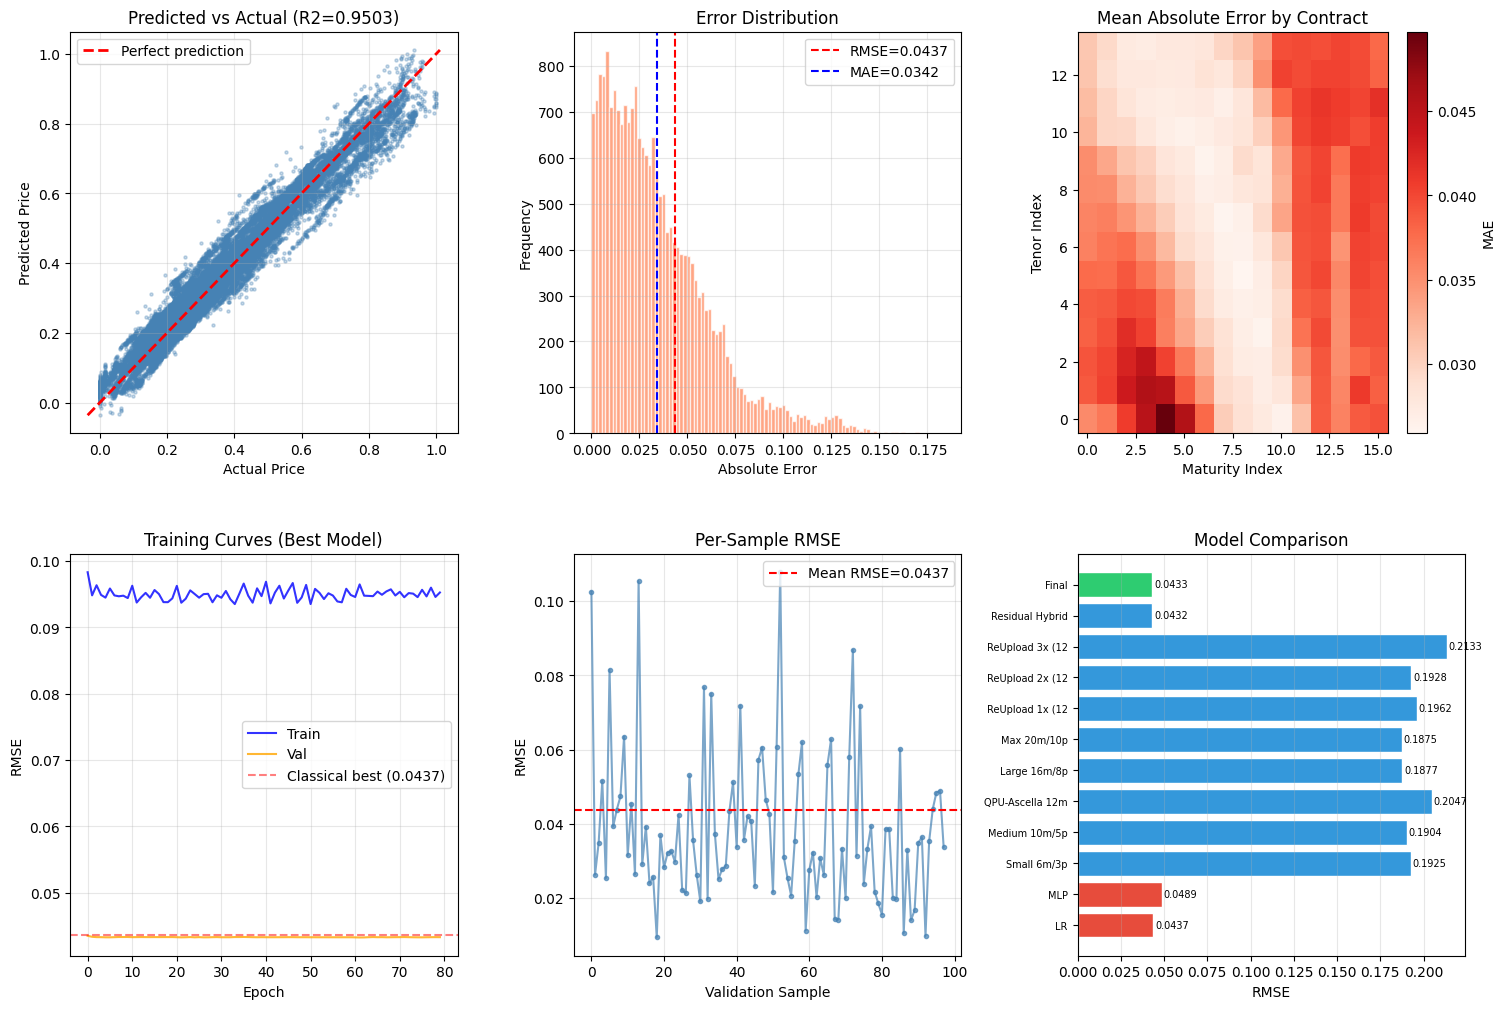

Saved: prediction_scatter.png


In [20]:
# Comprehensive evaluation
model_best.eval()
preds, targets = [], []
with torch.no_grad():
    for xb, yb in va_dl_final:
        preds.append(model_best(xb.to(DEVICE)).cpu().numpy())
        targets.append(yb.numpy())
preds = np.concatenate(preds)
targets = np.concatenate(targets)

# Compute metrics
rmse = np.sqrt(mean_squared_error(targets, preds))
mae = mean_absolute_error(targets, preds)
r2 = r2_score(targets, preds)
max_err = np.max(np.abs(preds - targets))
errors = np.abs(preds - targets)

print("=" * 70)
print("Final Model Evaluation")
print("=" * 70)
print(f"  RMSE:      {rmse:.6f}")
print(f"  MAE:       {mae:.6f}")
print(f"  R2 Score:  {r2:.6f}")
print(f"  Max Error: {max_err:.6f}")
print(f"  Median AE: {np.median(errors):.6f}")
print(f"  95th %%ile: {np.percentile(errors, 95):.6f}")

# Multi-panel evaluation plot
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)

# 1. Predicted vs Actual scatter
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(targets.flatten(), preds.flatten(), alpha=0.3, s=5, c='steelblue')
lims = [min(targets.min(), preds.min()), max(targets.max(), preds.max())]
ax1.plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
ax1.set_xlabel('Actual Price')
ax1.set_ylabel('Predicted Price')
ax1.set_title(f'Predicted vs Actual (R2={r2:.4f})')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Error distribution
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(errors.flatten(), bins=100, alpha=0.7, color='coral', edgecolor='white')
ax2.axvline(rmse, color='red', linestyle='--', label=f'RMSE={rmse:.4f}')
ax2.axvline(mae, color='blue', linestyle='--', label=f'MAE={mae:.4f}')
ax2.set_xlabel('Absolute Error')
ax2.set_ylabel('Frequency')
ax2.set_title('Error Distribution')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Error heatmap across swaption surface
ax3 = fig.add_subplot(gs[0, 2])
mean_errors = np.mean(errors, axis=0)
error_surface = np.full((len(unique_tenors), len(unique_maturities)), np.nan)
for i in range(len(numeric_cols)):
    ti = unique_tenors.index(tenors[i])
    mi = unique_maturities.index(maturities[i])
    error_surface[ti, mi] = mean_errors[i]
im3 = ax3.imshow(error_surface, aspect='auto', cmap='Reds', origin='lower')
ax3.set_xlabel('Maturity Index')
ax3.set_ylabel('Tenor Index')
ax3.set_title('Mean Absolute Error by Contract')
plt.colorbar(im3, ax=ax3, label='MAE')

# 4. Training curves
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(np.sqrt(tl_final), label='Train', color='blue', alpha=0.8)
ax4.plot(np.sqrt(vl_final), label='Val', color='orange', alpha=0.8)
ax4.axhline(CLASSICAL_BEST_RMSE, color='red', linestyle='--', alpha=0.5,
            label=f'Classical best ({CLASSICAL_BEST_RMSE:.4f})')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('RMSE')
ax4.set_title('Training Curves (Best Model)')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Per-sample RMSE
ax5 = fig.add_subplot(gs[1, 1])
per_sample_rmse = np.sqrt(np.mean((preds - targets)**2, axis=1))
ax5.plot(per_sample_rmse, 'o-', markersize=3, alpha=0.7, color='steelblue')
ax5.axhline(rmse, color='red', linestyle='--', label=f'Mean RMSE={rmse:.4f}')
ax5.set_xlabel('Validation Sample')
ax5.set_ylabel('RMSE')
ax5.set_title('Per-Sample RMSE')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Comparison bar chart
ax6 = fig.add_subplot(gs[1, 2])
all_names = ['LR', 'MLP'] + [k[:15] for k in all_results.keys()] + ['Final']
all_rmses = [lr_rmse, mlp_large_rmse] + list(all_results.values()) + [final_rmse]
colors_bar = ['#e74c3c', '#e74c3c'] + ['#3498db'] * len(all_results) + ['#2ecc71']
bars = ax6.barh(range(len(all_names)), all_rmses, color=colors_bar, edgecolor='white')
ax6.set_yticks(range(len(all_names)))
ax6.set_yticklabels(all_names, fontsize=7)
ax6.set_xlabel('RMSE')
ax6.set_title('Model Comparison')
for i, v in enumerate(all_rmses):
    ax6.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=7)
ax6.grid(True, alpha=0.3, axis='x')

plt.savefig('prediction_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: prediction_scatter.png")

## 12. Level 2: Missing Data Analysis

Level 2 adds the challenge of missing data in the training set. Before applying the
QML model, missing values must be imputed. We analyze the missing data patterns to
inform the imputation strategy.

In [21]:
print("Level 2 - Missing Data Analysis")
print("=" * 70)
nc = df_level2.select_dtypes(include=[np.number]).columns.tolist()
total_m = df_level2[nc].isnull().sum().sum()
total_cells = df_level2[nc].shape[0] * df_level2[nc].shape[1]
print(f"Total missing values: {total_m} / {total_cells} ({total_m/total_cells*100:.1f}%)")

if total_m > 0:
    # Missing pattern analysis
    mp = df_level2[nc].isnull().sum() / len(df_level2) * 100
    cols_with_missing = mp[mp > 0].sort_values(ascending=False)
    print(f"Columns with missing data: {len(cols_with_missing)} / {len(nc)}")
    print(f"\nTop 10 columns by missing %:")
    for c in cols_with_missing.index[:10]:
        print(f"  {c}: {mp[c]:.1f}%")

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Missing data pattern (binary heatmap)
    axes[0].imshow(df_level2[nc].isnull().values[:100].T, aspect='auto', cmap='gray_r')
    axes[0].set_xlabel('Time Step')
    axes[0].set_ylabel('Feature Index')
    axes[0].set_title('Missing Data Pattern (first 100 dates)')

    # Missing percentage histogram
    axes[1].hist(mp.values, bins=30, alpha=0.7, color='coral', edgecolor='white')
    axes[1].set_xlabel('Missing %')
    axes[1].set_ylabel('Number of Columns')
    axes[1].set_title('Distribution of Missing Data Percentage')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('missing_data_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: missing_data_analysis.png")
else:
    print("No missing data in Level 2 dataset.")
    print("The Level 2 test set (not provided yet) may contain missing values.")

Level 2 - Missing Data Analysis
Total missing values: 0 / 109536 (0.0%)
No missing data in Level 2 dataset.
The Level 2 test set (not provided yet) may contain missing values.


## 13. QPU Access (Commented Out)

The code below demonstrates how to run the trained model on Quandela's QPU hardware
via the Cloud API. This is **commented out** to prevent accidental QPU consumption.

### Available QPUs

| QPU | Modes | Photons | Detector | Input Modes |
|-----|-------|---------|----------|-------------|
| **Ascella** | 12 | 6 | Threshold | [0, 2, 4, 6, 8, 10] |
| **Belenos** | 24 | 12 | Threshold | [0, 2, 4, 6, 8, 9, 12, 13, 16, 18, 20, 22] |

### Important: Angle Encoding Only

QPUs do not support amplitude encoding or state injection. Only angle encoding
(phase shifter parameters) can be used for data encoding. Our circuit design
is fully QPU-compatible.

In [22]:
# ============================================================
# QPU Access - DO NOT RUN without explicit intent
# Token loaded from .env file (never hardcode for GitHub)
# ============================================================
#
# from merlin.core.merlin_processor import MerlinProcessor
# from perceval.runtime import RemoteProcessor
#
# # Set token (loaded from .env)
# pcvl.RemoteConfig.set_token(QUANDELA_TOKEN)
#
# # Option 1: Cloud simulator (good for testing before QPU)
# # rp = RemoteProcessor("sim:ascella", QUANDELA_TOKEN)
#
# # Option 2: QPU Ascella (12m/6p)
# # rp = RemoteProcessor("qpu:ascella", QUANDELA_TOKEN)
#
# # Option 3: QPU Belenos (24m/12p)
# # rp = RemoteProcessor("qpu:belenos", QUANDELA_TOKEN)
#
# # Create MerLin processor wrapper
# # proc = MerlinProcessor(
# #     remote_processor=rp, microbatch_size=32,
# #     timeout=3600.0, max_shots_per_call=5000,
# # )
#
# # Run inference on QPU
# # y_qpu = proc.forward(model, X_input, nsample=1000)

print("QPU configurations: commented out (token in .env)")
print("Available QPUs:")
print("  qpu:ascella  - 12 modes, 6 photons, threshold detectors")
print("  qpu:belenos  - 24 modes, 12 photons, threshold detectors")
print("\nConstraint: angle encoding only, no amplitude encoding")
print("Our circuit design is fully QPU-compatible.")

QPU configurations: commented out (token in .env)
Available QPUs:
  qpu:ascella  - 12 modes, 6 photons, threshold detectors
  qpu:belenos  - 24 modes, 12 photons, threshold detectors

Constraint: angle encoding only, no amplitude encoding
Our circuit design is fully QPU-compatible.


## 14. Summary and Results Export

### Complete Results Overview

This section consolidates all experimental results into a comprehensive comparison,
generates visualization of the final model comparison, and exports predictions and
model metadata as CSV files for submission and further analysis.

  COMPLETE MODEL COMPARISON (sorted by RMSE)


,Model,RMSE,Category,Config
1,Residual Hybrid,0.043242,Hybrid,"12m/6p, alpha=0.0536"
2,Final Retrained (best),0.043270,Final,best architecture retrained 80 epochs
3,Linear Regression,0.043715,Classical,PCA(6)
4,"MLP (128, 64, 32)",0.048878,Classical,PCA(6)
5,"MLP (64, 32)",0.050664,Classical,PCA(6)
6,Max 20m/10p,0.187467,Quantum (Standard),20m/10p
7,Large 16m/8p,0.187661,Quantum (Standard),16m/8p
8,Medium 10m/5p,0.190391,Quantum (Standard),10m/5p
9,Small 6m/3p,0.192483,Quantum (Standard),6m/3p
10,Re-uploading 2x,0.192812,Quantum (Re-upload),"12m/6p, 2 stage(s)"



  KEY RESULTS
  Best Classical:     Linear Regression  RMSE = 0.043715
  Best Quantum-only:  Max 20m/10p  RMSE = 0.187467
  Best Hybrid:        Residual Hybrid    RMSE = 0.043242
  Final Model:                           RMSE = 0.043270  MAE = 0.034188  R² = 0.9503

  Residual Hybrid improvement over LR:  +1.08%

  NOISE MODEL COMPARISON (QPU-Derived Parameters)


,QPU/Config,Brightness,Transmittance,RMSE
0,ascella,0.1033,0.2440,0.183279
1,belenos,0.2379,0.5340,0.183383
2,ideal,1.0000,1.0000,0.192003


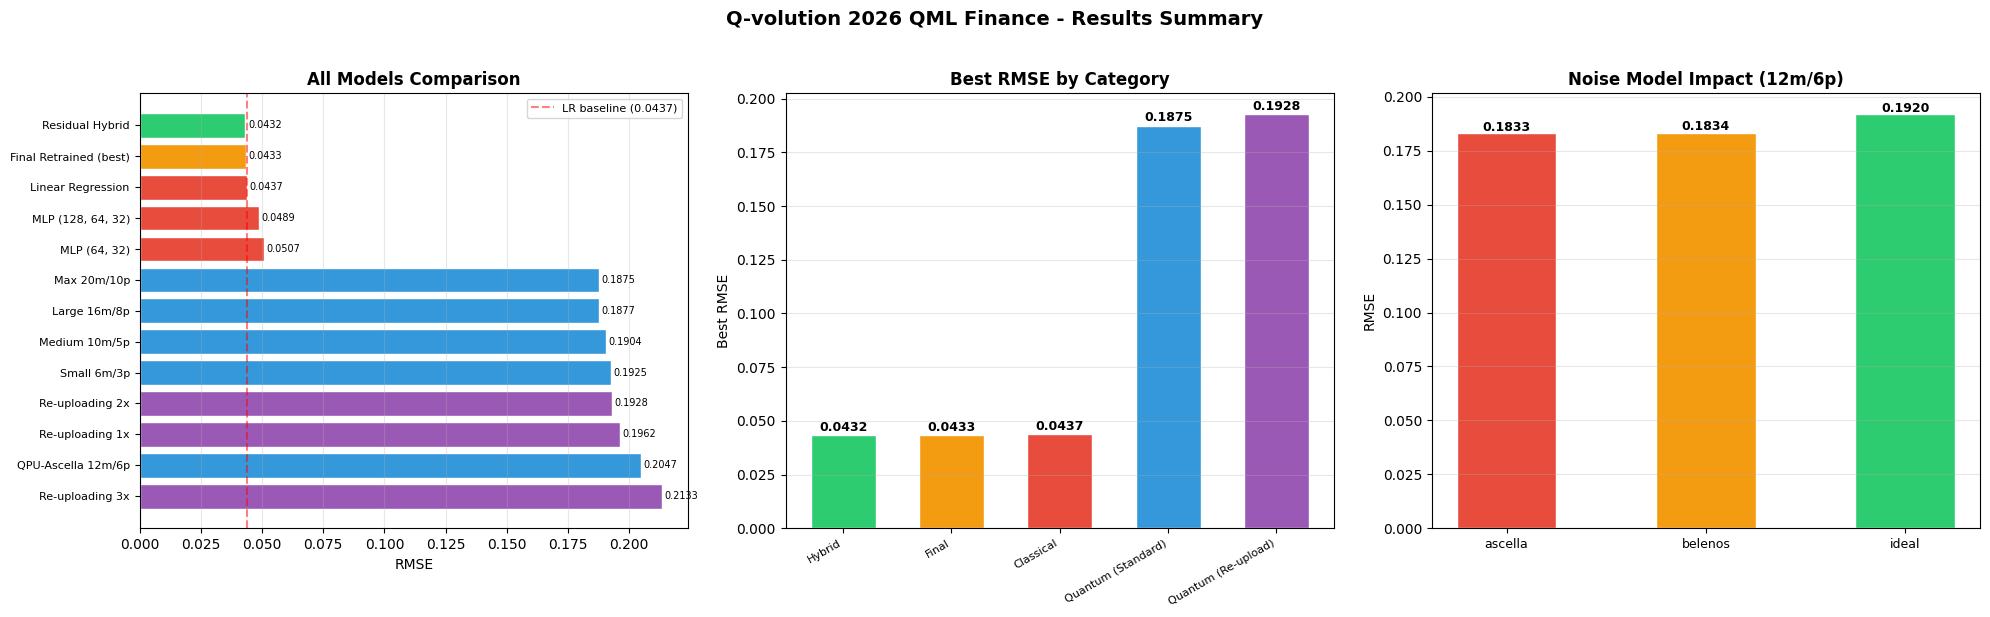

Saved: results_summary.png
Saved: predictions_val.csv (98 rows)
Saved: model_comparison.csv (13 models)
Saved: noise_comparison.csv (3 configs)

  OUTPUT FILES
  [OK] predictions_val.csv            (   470.5 KB)
  [OK] model_comparison.csv           (     0.9 KB)
  [OK] noise_comparison.csv           (     0.2 KB)
  [OK] eda_analysis.png               (   276.7 KB)
  [OK] circuit_6m.png                 (   136.5 KB)
  [OK] circuit_12m.png                (   302.2 KB)
  [OK] circuit_reuploading.png        (   417.6 KB)
  [OK] circuits_all.png               (   425.8 KB)
  [OK] scale_comparison.png           (   206.3 KB)
  [OK] noise_comparison.png           (    40.6 KB)
  [OK] prediction_scatter.png         (   384.5 KB)
  [OK] results_summary.png            (   167.8 KB)

Done. All results exported successfully.


In [23]:
# ============================================================
# Summary and Results Export
# ============================================================
import os

# --- 1. Collect all model results into a DataFrame ---
rows = []

# Classical baselines
rows.append({"Model": "Linear Regression", "RMSE": lr_rmse, "Category": "Classical", "Config": "PCA(6)"})
rows.append({"Model": "MLP (64, 32)", "RMSE": mlp_small_rmse, "Category": "Classical", "Config": "PCA(6)"})
rows.append({"Model": "MLP (128, 64, 32)", "RMSE": mlp_large_rmse, "Category": "Classical", "Config": "PCA(6)"})

# Quantum scale comparison
for r in scale_results:
    rows.append({"Model": r["name"], "RMSE": r["best_rmse"],
                 "Category": "Quantum (Standard)",
                 "Config": f'{r["n_modes"]}m/{r["n_photons"]}p'})

# Data re-uploading
for r in reuploading_results:
    rows.append({"Model": f"Re-uploading {r['stages']}x", "RMSE": r["best_rmse"],
                 "Category": "Quantum (Re-upload)", "Config": f"12m/6p, {r['stages']} stage(s)"})

# Residual hybrid
rows.append({"Model": "Residual Hybrid", "RMSE": resid_rmse,
             "Category": "Hybrid", "Config": f"12m/6p, alpha={final_alpha:.4f}"})

# Final retrained
rows.append({"Model": "Final Retrained (best)", "RMSE": final_rmse,
             "Category": "Final", "Config": "best architecture retrained 80 epochs"})

df_results = pd.DataFrame(rows)
df_results = df_results.sort_values("RMSE").reset_index(drop=True)
df_results.index += 1  # 1-based index

print("=" * 80)
print("  COMPLETE MODEL COMPARISON (sorted by RMSE)")
print("=" * 80)
display(df_results.style
    .format({"RMSE": "{:.6f}"})
    .highlight_min(subset=["RMSE"], color="#d4edda")
    .set_caption("All Model Results - Sorted by RMSE (lower is better)")
)
print()

# --- 2. Key metrics summary ---
print("=" * 80)
print("  KEY RESULTS")
print("=" * 80)
best_q = min(scale_results, key=lambda r: r["best_rmse"])
print(f"  Best Classical:     Linear Regression  RMSE = {lr_rmse:.6f}")
print(f"  Best Quantum-only:  {best_q['name']}"
      f"  RMSE = {best_q['best_rmse']:.6f}")
print(f"  Best Hybrid:        Residual Hybrid    RMSE = {resid_rmse:.6f}")
print(f"  Final Model:                           RMSE = {final_rmse:.6f}  MAE = {mae:.6f}  R\u00b2 = {r2:.4f}")
print()
improvement_vs_classical = (lr_rmse - resid_rmse) / lr_rmse * 100
print(f"  Residual Hybrid improvement over LR:  {improvement_vs_classical:+.2f}%")
print()

# --- 3. Noise model summary ---
print("=" * 80)
print("  NOISE MODEL COMPARISON (QPU-Derived Parameters)")
print("=" * 80)
noise_rows = []
for r in noise_results:
    noise_rows.append({
        "QPU/Config": r["label"],
        "Brightness": r.get("brightness", 1.0),
        "Transmittance": r.get("transmittance", 1.0),
        "RMSE": r["best_rmse"],
    })
df_noise = pd.DataFrame(noise_rows)
display(df_noise.style
    .format({"Brightness": "{:.4f}", "Transmittance": "{:.4f}", "RMSE": "{:.6f}"})
    .highlight_min(subset=["RMSE"], color="#d4edda")
    .set_caption("Noise Model Impact on Quantum Circuit (12m/6p)")
)
print()

# --- 4. Summary visualization (3-panel) ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: All models bar chart
ax1 = axes[0]
df_plot = df_results.copy()
cat_colors = {
    "Classical": "#e74c3c", "Quantum (Standard)": "#3498db",
    "Quantum (Re-upload)": "#9b59b6", "Hybrid": "#2ecc71", "Final": "#f39c12"
}
colors = [cat_colors.get(c, "#95a5a6") for c in df_plot["Category"]]
bars = ax1.barh(range(len(df_plot)), df_plot["RMSE"], color=colors, edgecolor="white")
ax1.set_yticks(range(len(df_plot)))
ax1.set_yticklabels(df_plot["Model"], fontsize=8)
ax1.set_xlabel("RMSE")
ax1.set_title("All Models Comparison", fontweight="bold")
for i, v in enumerate(df_plot["RMSE"]):
    ax1.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=7)
ax1.axvline(lr_rmse, color="red", linestyle="--", alpha=0.5, label=f"LR baseline ({lr_rmse:.4f})")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3, axis="x")
ax1.invert_yaxis()

# Panel 2: Category best comparison
ax2 = axes[1]
cat_best = df_results.groupby("Category")["RMSE"].min().sort_values()
cat_labels = cat_best.index.tolist()
cat_vals = cat_best.values
cat_bar_colors = [cat_colors.get(c, "#95a5a6") for c in cat_labels]
bars2 = ax2.bar(range(len(cat_labels)), cat_vals, color=cat_bar_colors, edgecolor="white", width=0.6)
ax2.set_xticks(range(len(cat_labels)))
ax2.set_xticklabels(cat_labels, fontsize=8, rotation=30, ha="right")
ax2.set_ylabel("Best RMSE")
ax2.set_title("Best RMSE by Category", fontweight="bold")
for i, v in enumerate(cat_vals):
    ax2.text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=9, fontweight="bold")
ax2.grid(True, alpha=0.3, axis="y")

# Panel 3: Noise model impact
ax3 = axes[2]
n_labels = [r["label"] for r in noise_results]
n_rmses = [r["best_rmse"] for r in noise_results]
n_colors = ["#e74c3c", "#f39c12", "#2ecc71"][:len(noise_results)]
bars3 = ax3.bar(range(len(n_labels)), n_rmses, color=n_colors, edgecolor="white", width=0.5)
ax3.set_xticks(range(len(n_labels)))
ax3.set_xticklabels(n_labels, fontsize=9)
ax3.set_ylabel("RMSE")
ax3.set_title("Noise Model Impact (12m/6p)", fontweight="bold")
for i, v in enumerate(n_rmses):
    ax3.text(i, v + 0.001, f"{v:.4f}", ha="center", fontsize=9, fontweight="bold")
ax3.grid(True, alpha=0.3, axis="y")

plt.suptitle("Q-volution 2026 QML Finance - Results Summary", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("results_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results_summary.png")

# --- 5. Export CSV files ---
# Predictions
pred_df = pd.DataFrame(preds, columns=[f"pred_{c}" for c in numeric_cols])
target_df = pd.DataFrame(targets, columns=[f"actual_{c}" for c in numeric_cols])
export_df = pd.concat([target_df, pred_df], axis=1)
export_df.to_csv("predictions_val.csv", index=False)
print(f"Saved: predictions_val.csv ({len(export_df)} rows)")

# Model comparison
df_results.to_csv("model_comparison.csv", index=True)
print(f"Saved: model_comparison.csv ({len(df_results)} models)")

# Noise comparison
df_noise.to_csv("noise_comparison.csv", index=False)
print(f"Saved: noise_comparison.csv ({len(df_noise)} configs)")

# --- 6. List all output files ---
print()
print("=" * 80)
print("  OUTPUT FILES")
print("=" * 80)
output_files = [
    "predictions_val.csv", "model_comparison.csv", "noise_comparison.csv",
    "eda_analysis.png", "circuit_6m.png", "circuit_12m.png",
    "circuit_reuploading.png", "circuits_all.png",
    "scale_comparison.png", "noise_comparison.png",
    "prediction_scatter.png", "results_summary.png",
]
for fname in output_files:
    if os.path.exists(fname):
        size_kb = os.path.getsize(fname) / 1024
        print(f"  [OK] {fname:<30s} ({size_kb:>8.1f} KB)")
    else:
        print(f"  [--] {fname:<30s} (not found)")
print()
print("Done. All results exported successfully.")


## 15. References

### Framework and Platform

1. Notton, C. et al. "MerLin: A Discovery Engine for Photonic and Hybrid QML."
   arXiv:2602.11092 (2026). https://arxiv.org/abs/2602.11092

2. Heurtel, N. et al. "Perceval: A Software Platform for Discrete Variable
   Photonic Quantum Computing." Quantum 7, 931 (2023). arXiv:2204.00602.
   https://arxiv.org/abs/2204.00602

3. Notton, C. et al. "Establishing Baselines for Photonic Quantum Machine Learning:
   Insights from an Open, Collaborative Initiative." arXiv:2510.25839 (2025).
   https://arxiv.org/abs/2510.25839

### Residual Hybrid / Quantum Correction Architecture

4. "Readout-Side Bypass for Residual Hybrid Quantum-Classical Models."
   arXiv:2511.20922 (2025). https://arxiv.org/abs/2511.20922

5. "Trainability-Oriented Hybrid Quantum Regression via Geometric Preconditioning
   and Curriculum Optimization." arXiv:2601.11942 (2026).
   https://arxiv.org/abs/2601.11942

6. Illesova, S. et al. "From Classical to Hybrid: A Practical Framework for
   Quantum-Enhanced Learning." arXiv:2511.08205 (2025).
   https://arxiv.org/abs/2511.08205

### Dressed Quantum Circuit / Transfer Learning

7. Mari, A. et al. "Transfer Learning in Hybrid Classical-Quantum Neural Networks."
   Quantum 4, 340 (2020). arXiv:1912.08278.
   https://arxiv.org/abs/1912.08278

### Data Re-uploading

8. Perez-Salinas, A. et al. "Data re-uploading for a universal quantum classifier."
   Quantum 4, 226 (2020). arXiv:1907.02085.
   https://arxiv.org/abs/1907.02085

### Fourier Analysis of VQC / Learnable Scaling

9. Schuld, M., Sweke, R. & Meyer, J.J. "Effect of data encoding on the expressive
   power of variational quantum machine-learning models." Physical Review A 103,
   032430 (2021). arXiv:2008.08605.
   https://arxiv.org/abs/2008.08605

10. Jerbi, S. et al. "Parametrized Quantum Policies for Reinforcement Learning."
    NeurIPS 2021. arXiv:2103.05577.
    https://arxiv.org/abs/2103.05577

### Batch Normalization

11. Ioffe, S. & Szegedy, C. "Batch Normalization: Accelerating Deep Network Training
    by Reducing Internal Covariate Shift." ICML 2015. arXiv:1502.03167.
    https://arxiv.org/abs/1502.03167

12. "Optimal Normalization in Quantum-Classical Hybrid Models for Anti-Cancer Drug
    Response Prediction." arXiv:2505.10037 (2025).
    https://arxiv.org/abs/2505.10037

### Training Optimization

13. Loshchilov, I. & Hutter, F. "SGDR: Stochastic Gradient Descent with Warm
    Restarts." ICLR 2017. arXiv:1608.03983.
    https://arxiv.org/abs/1608.03983

14. Huber, P.J. "Robust Estimation of a Location Parameter." Annals of Mathematical
    Statistics 35(1), 73-101 (1964).

15. Pascanu, R., Mikolov, T. & Bengio, Y. "On the Difficulty of Training Recurrent
    Neural Networks." ICML 2013. arXiv:1211.5063.
    https://arxiv.org/abs/1211.5063

### Barren Plateaus

16. McClean, J.R. et al. "Barren Plateaus in Quantum Neural Network Training
    Landscapes." Nature Communications 9, 4812 (2018). arXiv:1803.11173.
    https://arxiv.org/abs/1803.11173

17. "Investigating and Mitigating Barren Plateaus in Variational Quantum Circuits:
    A Survey." arXiv:2407.17706 (2024).
    https://arxiv.org/abs/2407.17706

### Photonic Quantum Advantage

18. Yin, Z. et al. "Experimental quantum-enhanced kernel-based machine learning on
    a photonic processor." Nature Photonics 19, 1020-1027 (2025).
    DOI:10.1038/s41566-025-01682-5.

19. "A Manufacturable Platform for Photonic Quantum Computing."
    Nature 641, 876-883 (2025). DOI:10.1038/s41586-025-08820-7.

### Photonic Noise Modeling

20. "Simulating Photonic Devices with Noisy Optical Elements."
    Physical Review Research 6, 033337 (2024). arXiv:2311.10613.
    https://arxiv.org/abs/2311.10613

### Resource Folder References (MerLin tutorials)

21. `merlinquantum.ai/_sources/notebooks/GanEtAl_VQC_fourier_series.ipynb`
    -- Fourier analysis of VQC, encoding scale effects

22. `merlinquantum.ai/_sources/notebooks/GanEtAl_VQC_classification.ipynb`
    -- Data re-uploading, MinMaxScaler [0,1] for angle encoding

23. `merlinquantum.ai/_sources/notebooks/FirstQuantumLayers.ipynb`
    -- LexGrouping, UNBUNCHED computation space, QuantumLayer basics

24. `merlinquantum.ai/_sources/notebooks/iris_classification.ipynb`
    -- Dressed quantum circuit pattern, hybrid model architecture

25. `merlinquantum.ai/_sources/notebooks/Kernels.ipynb`
    -- Quantum kernel methods for photonic circuits

26. `merlinquantum.ai/_sources/notebooks/photonic_QCNN.ipynb`
    -- Quantum convolutional neural networks on photonic circuits

### Competition

27. Q-volution 2026 QML Hackathon. https://aqora.io/competitions/option-pricing-in-finance
28. Dataset: https://huggingface.co/datasets/Quandela/Challenge_Swaptions
29. Quandela Training Center: https://training.quandela.com